# Dự án: Dự đoán kết quả học tập dựa trên dữ liệu hành vi và sinh hoạt.

**Nhóm thực hiện:** Nhóm 13

| Họ và tên             | MSSV     |
|-----------------------|----------|
| Nguyễn Hồng Thảo Minh  | 23280019 |
| Đinh Bình An           | 23280034 |
| Trần Phong Phú         | 23280077 |
| Lưu Vũ Lâm             | 23280067 |
| Nguyễn Đức Huy         | 23280062 |


book-laptop-pencil-clock-wooden-table-library-education-learning-concept_1150-16629.avif

# 📖 **1. Giới thiệu vấn đề**

Trong bối cảnh giáo dục hiện đại, việc nâng cao chất lượng học tập và hỗ trợ sinh viên đạt được kết quả tốt là mục tiêu quan trọng của các trường đại học và các cơ sở đào tạo. Tuy nhiên, mỗi sinh viên đều có đặc điểm riêng biệt về thông tin cá nhân, thói quen học tập và các yếu tố tác động đến hiệu quả học tập. Do đó, việc xây dựng một mô hình dự đoán điểm học tập dựa trên các dữ liệu liên quan đến thông tin cá nhân và thói quen học tập sẽ giúp nhà trường, giảng viên và chính bản thân sinh viên có cái nhìn sâu sắc hơn về khả năng học tập của từng cá nhân.

Mô hình dự đoán không chỉ giúp dự báo chính xác kết quả học tập mà còn hỗ trợ phân tích các yếu tố ảnh hưởng, từ đó đề xuất các biện pháp phù hợp nhằm nâng cao thành tích học tập và cải thiện thói quen sinh hoạt của sinh viên.

**Mục tiêu của bài toán**:

- 📊 Phân tích sơ bộ để hiểu các yếu tố ảnh hưởng đến kết quả học tập
- 📝 Xây dựng mô hình dự đoán điểm học tập của sinh viên.



**Bộ dữ liệu** được sử dụng trong bài toán bao gồm thông tin về thói quen học tập, sinh hoạt, sức khỏe tinh thần cùng điểm số thực tế của các sinh viên, tạo nền tảng để phát triển và đánh giá mô hình dự đoán.

**Nguồn**: https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance


In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from scipy.stats import ttest_ind, f_oneway
from sklearn.preprocessing import MinMaxScaler
import kagglehub


In [52]:
# Tải dữ liệu về
path = kagglehub.dataset_download("jayaantanaath/student-habits-vs-academic-performance")

# Xuất đường dẫn đến thư mục chứ data
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/student-habits-vs-academic-performance


In [53]:
df = pd.read_csv('/kaggle/input/student-habits-vs-academic-performance/student_habits_performance.csv')

In [54]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

| Cột                    | Kiểu dữ liệu | Mô tả                                                                                |
| :--------------------- | :----------- | :----------------------------------------------------------------------------------- |
| `study_hours_per_day`  | float        | Số giờ học trung bình mỗi ngày của sinh viên                                         |
| `exam_score`           | float        | Điểm thi cuối kỳ (thang điểm 100)                                                    |
| `social_media_hours`   | float        | Số giờ dùng mạng xã hội mỗi ngày                                                     |
| `netflix_hours`        | float        | Số giờ xem Netflix mỗi ngày                                                          |
| `sleep_hours`          | float        | Số giờ ngủ trung bình mỗi ngày                                                       |
| `diet_quality`         | object       | Chất lượng chế độ ăn uống (`Poor`, `Average`, `Good`)                                |
| `parental_education`   | object       | Trình độ học vấn cao nhất của cha mẹ (`None`, `Highschool`, `College`, `University`) |
| `internet_quality`     | object       | Chất lượng mạng Internet ở nhà (`Poor`, `Average`, `Good`)                           |
| `part_time_job`        | object       | Sinh viên có việc làm thêm không (`Yes`, `No`)                                       |
| `mental_health_rating` | int64        | Thang điểm đánh giá sức khỏe tinh thần: 1 (rất tệ) → 10 (rất tốt)                    |
| `exercise_frequency`   | float        | Tần suất tập thể dục mỗi tuần (số buổi/tuần)                                         |


#📊 2. Dữ liệu & EDA

In [56]:
# Hàm kiểm tra missing data
def check_missing_data(df):
  if df.isnull().sum().sum() == 0:
    print("No missing data")
  else:
    print("Missing data")
  for col in df.columns:
      if df[col].isnull().sum() > 0:
        percentage = df[col].isnull().sum() / len(df) * 100
        print(f"Column {col} has {df[col].isnull().sum()} missing value ({percentage}%)")

In [57]:
# Kiểm tra missing data
check_missing_data(df)

Missing data
Column parental_education_level has 91 missing value (9.1%)


In [58]:
# Kiểm tra các dòng có cột parental_education_level bị thiếu
df[df['parental_education_level'].isnull()]

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
10,S1010,19,Female,4.6,3.7,0.8,No,77.6,5.8,Fair,1,NaN,Good,3,No,63.3
33,S1033,18,Female,4.0,0.9,1.1,No,99.5,5.8,Poor,2,NaN,Average,5,No,70.7
47,S1047,23,Female,2.5,2.9,2.7,No,83.5,7.0,Good,4,NaN,Good,8,Yes,59.7
74,S1074,21,Female,2.3,1.0,0.4,No,100.0,6.4,Fair,6,NaN,Good,1,No,66.9
93,S1093,22,Male,4.1,2.5,3.0,No,85.1,5.8,Good,4,NaN,Good,5,No,70.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
921,S1921,23,Female,4.4,2.7,1.0,No,79.8,6.1,Fair,6,NaN,Average,3,No,85.4
925,S1925,19,Other,1.7,2.9,1.6,Yes,97.3,8.7,Good,1,NaN,Good,7,No,53.6
939,S1939,18,Female,4.7,3.2,1.9,No,75.2,5.4,Good,3,NaN,Good,6,No,71.0
945,S1945,23,Male,6.0,2.9,2.1,Yes,98.9,6.4,Poor,0,NaN,Average,7,No,100.0


In [59]:
# Hàm vẽ biểu đồ cột cho cột bất kì (có %)
def plot_barplot_with_percentage(df, column, title):
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(x=column, data=df, order=df[column].value_counts().index, palette='viridis')

    # Thêm số lượng và phần trăm trên mỗi cột
    total = len(df)
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2.,
                height + 3,
                f'({height/total:.1%})',
                ha="center")

    plt.title(title,color='#00008b',fontweight='bold')
    plt.xlabel(column,color='#0000ff',fontweight='bold')
    plt.ylabel("Count",color='#0000ff',fontweight='bold')
    plt.tight_layout()
    plt.show()

<ipython-input-59-34604ea8c9f9>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, order=df[column].value_counts().index, palette='viridis')


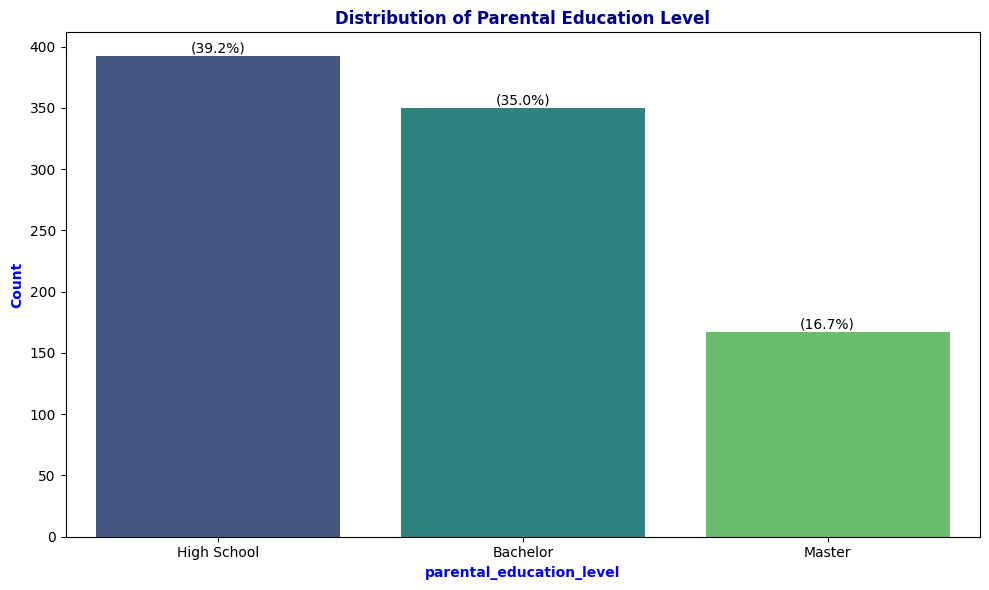

In [60]:
# Vẽ biểu đồ cột cho cột parental_education_level
plot_barplot_with_percentage(df, 'parental_education_level', 'Distribution of Parental Education Level')

<ipython-input-61-4bacf8c2da95>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='parental_education_level', y='exam_score', data=df,palette='Blues')


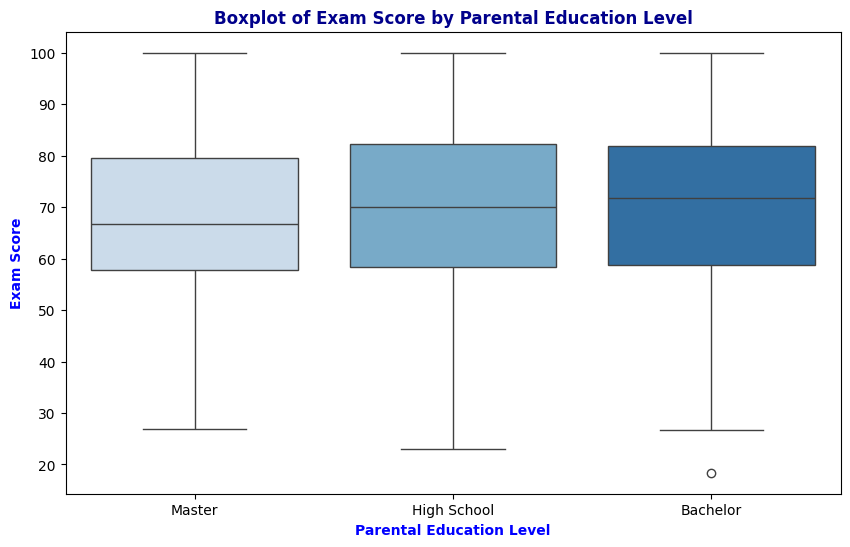

In [61]:
# Vẽ biểu hộp cho exam_score theo cột parental_education_level
plt.figure(figsize=(10, 6))
sns.boxplot(x='parental_education_level', y='exam_score', data=df,palette='Blues')
plt.title('Boxplot of Exam Score by Parental Education Level',color='#00008b',fontweight='bold')
plt.xlabel('Parental Education Level',color='#0000ff',fontweight='bold')
plt.ylabel('Exam Score',color='#0000ff',fontweight='bold')
plt.show()

**Nhận xét:**
-  Vì High School và Bachelor chiếm đa số và gần bằng nhau => Không có giá trị mode vượt trội
- Giá trị missing lại chiếm 9.1% (khá cao) nên không nên xóa vì có thể bị mất thông tin
- Dựa vào biểu đồ hộp, thấy có sự khác biệt nhẹ giữa điểm của học sinh có cha mẹ có các cấp giáo dục khác nhau => ta có thể tạm suy đoán là có mối hệ gì đó giữa trình độ học của cha mẹ và điểm con cái họ (suy đoán) => có thể là một biến tiềm năng để đưa vào mô hình

Do đó cách giải quyết là ta sẽ điền các giá trị missing bằng "Unknown" để tránh thiên lệch cho một nhớm cũng như giữ đủ dữ liệu cho mô hình ở các cột còn lại

In [62]:
# Thay các giá trị thiếu cột parental_education_level thành 'Unknown'
df['parental_education_level'] = df['parental_education_level'].fillna('Unknown')

In [63]:
# Kiểm tra lại
check_missing_data(df)

No missing data


In [64]:
# Kiểm tra giá trị trùng lặp
df.duplicated().sum()

np.int64(0)

In [65]:
# Kiểm tra số lượng giá trị duy nhất mỗi cột
df.nunique()

,0
student_id,1000
age,8
gender,3
study_hours_per_day,78
social_media_hours,60
netflix_hours,51
part_time_job,2
attendance_percentage,320
sleep_hours,68
diet_quality,3


In [66]:
#Kiểm tra tính đồng nhất
#Chọn ra các cột có số giá trị duy nhất bé hơn bằng 30
categorical_cols = [col for col in df.select_dtypes(include=['object']).columns if df[col].nunique() <= 30]
print("Identify categorical columns with 30 or fewer unique valuesc:", categorical_cols)


Identify categorical columns with 30 or fewer unique valuesc: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


In [67]:
for col in categorical_cols:
    print(f"🔹 Column: {col}")
    print(df[col].value_counts(dropna=False))
    print("-" * 50)

🔹 Column: gender
gender
Female    481
Male      477
Other      42
Name: count, dtype: int64
--------------------------------------------------
🔹 Column: part_time_job
part_time_job
No     785
Yes    215
Name: count, dtype: int64
--------------------------------------------------
🔹 Column: diet_quality
diet_quality
Fair    437
Good    378
Poor    185
Name: count, dtype: int64
--------------------------------------------------
🔹 Column: parental_education_level
parental_education_level
High School    392
Bachelor       350
Master         167
Unknown         91
Name: count, dtype: int64
--------------------------------------------------
🔹 Column: internet_quality
internet_quality
Good       447
Average    391
Poor       162
Name: count, dtype: int64
--------------------------------------------------
🔹 Column: extracurricular_participation
extracurricular_participation
No     682
Yes    318
Name: count, dtype: int64
--------------------------------------------------


**Nhận xét:**

Cột duy nhất hơi có vấn đề là cột gender, có 41 giá trị 'Other'


<ipython-input-59-34604ea8c9f9>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, order=df[column].value_counts().index, palette='viridis')


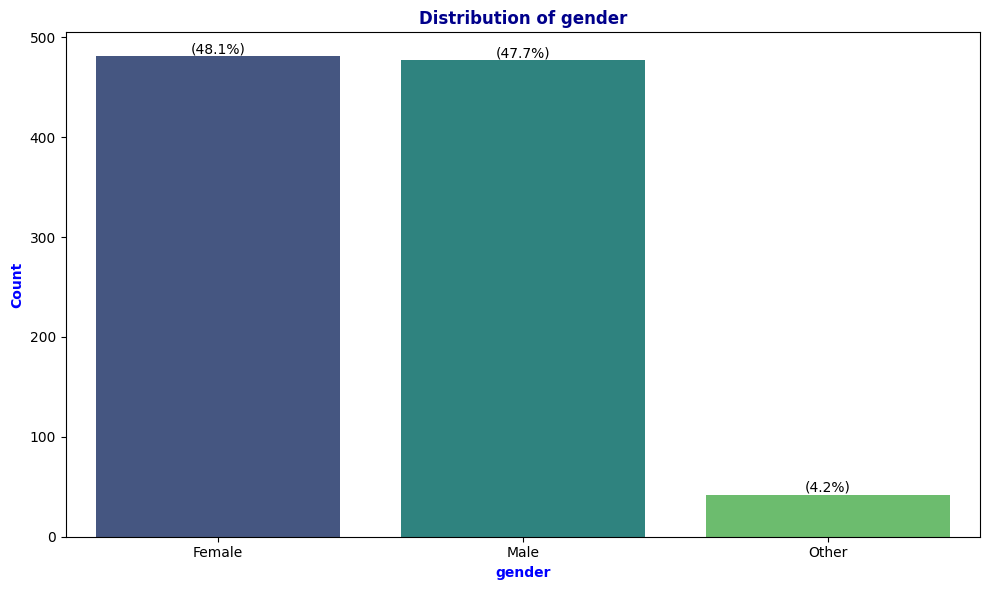

In [68]:
# Vẽ biểu đồ cột cho cột gender
plot_barplot_with_percentage(df,'gender','Distribution of gender')

In [69]:
# Kiểm tra điểm trung bình
df.groupby('gender')['exam_score'].mean()


,exam_score
gender,
Female,69.741372
Male,69.368344
Other,70.647619


<ipython-input-70-5ab1c5bcbdb2>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gender', y='exam_score', data=df,palette='Blues')


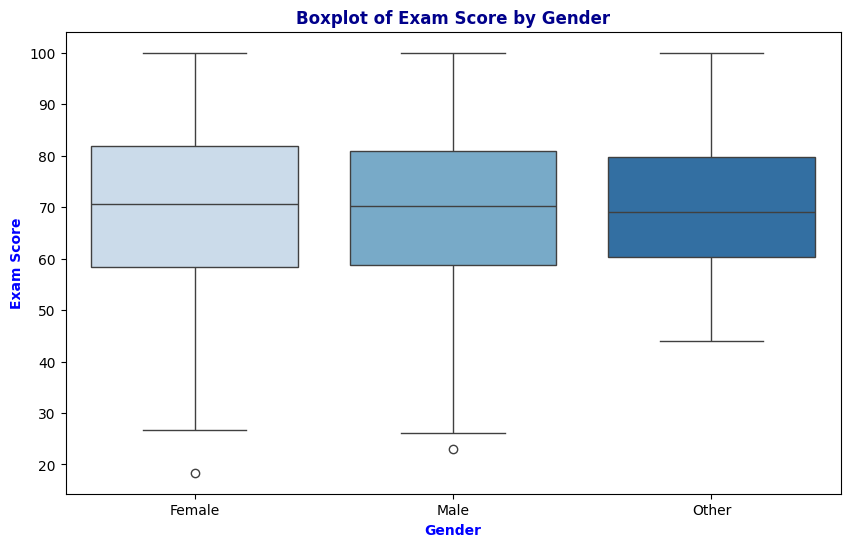

In [70]:
# Vẽ biểu hộp cho exam_score theo cột gender
plt.figure(figsize=(10, 6))
sns.boxplot(x='gender', y='exam_score', data=df,palette='Blues')
plt.title('Boxplot of Exam Score by Gender',color='#00008b',fontweight='bold')
plt.xlabel('Gender',color='#0000ff',fontweight='bold')
plt.ylabel('Exam Score',color='#0000ff',fontweight='bold')
plt.show()

**Nhận xét:**
- Ta nhận thấy điểm trung bình giữa male, female hay Other gần như không có khác biệt.
- Từ biểu đồ hộp, ta thấy giới tính không ảnh hưởng rõ rệt đến phân phối điểm của học sinh

=> Vì lẽ đó nên biến gender có vẻ không phải là một biến tiềm năng để đưa vào huấn luyện mô hình. Vì lẽ đó nên ta có thể chọn cách là xóa luôn cột gender hoặc để nguyên như vậy. Ở đây mình sẽ xóa cột gender


In [71]:
# Xóa cột gender
df.drop('gender', axis=1, inplace=True)

In [72]:
# Kiểm tra lại
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   study_hours_per_day            1000 non-null   float64
 3   social_media_hours             1000 non-null   float64
 4   netflix_hours                  1000 non-null   float64
 5   part_time_job                  1000 non-null   object 
 6   attendance_percentage          1000 non-null   float64
 7   sleep_hours                    1000 non-null   float64
 8   diet_quality                   1000 non-null   object 
 9   exercise_frequency             1000 non-null   int64  
 10  parental_education_level       1000 non-null   object 
 11  internet_quality               1000 non-null   object 
 12  mental_health_rating           1000 non-null   in

In [73]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


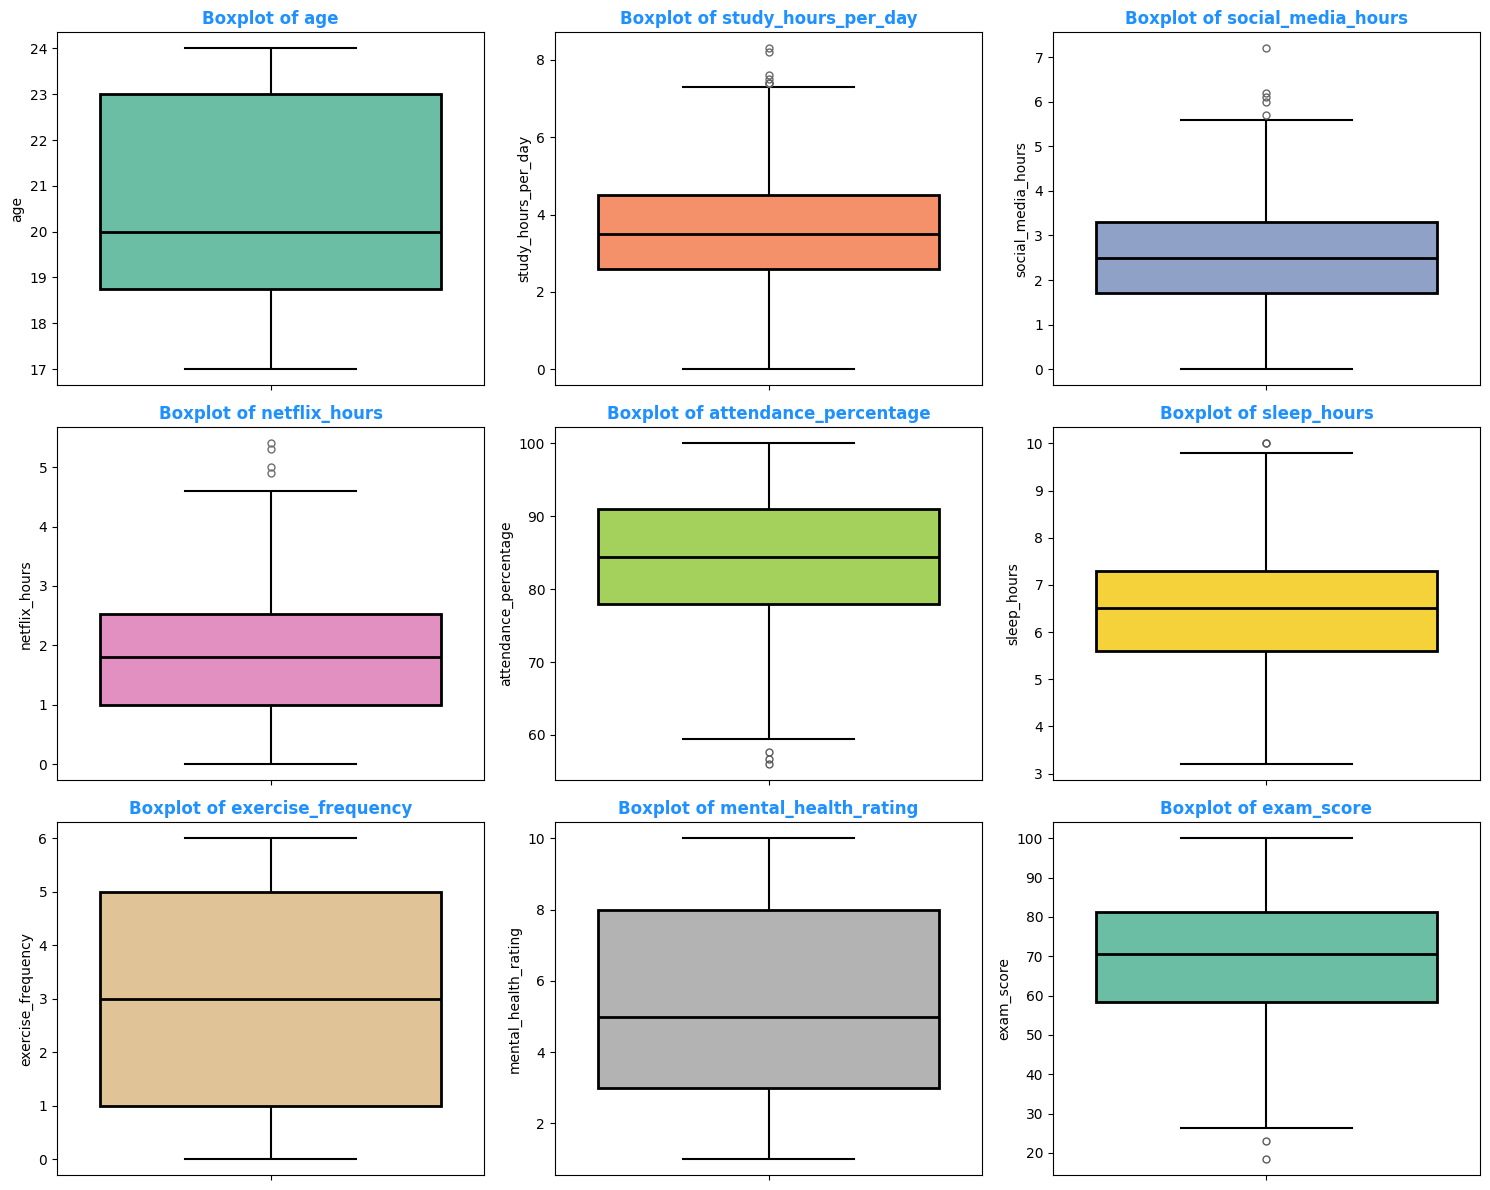

In [74]:
# Vẽ biểu đồ boxplot cho tất cả biến liên tục
# Các biến liên tục
numeric_cols = df.select_dtypes(include='number').columns

# Số biểu đồ cần vẽ
num_plots = len(numeric_cols)

# Tạo figure với lưới 3 hàng 3 cột
rows, cols = 3, 3
fig, axes = plt.subplots(rows, cols, figsize=(15, 12))
axes = axes.flatten()

# Tạo bảng màu Set2 với số màu = số biến
palette = sns.color_palette("Set2", n_colors=num_plots)

# Vẽ từng boxplot vào từng ô với màu riêng
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color=palette[i],
                saturation=0.9, linewidth=2,
                boxprops=dict(edgecolor='black'),
                medianprops=dict(color='black', linewidth=2),
                whiskerprops=dict(color='black', linewidth=1.5),
                capprops=dict(color='black', linewidth=1.5),
                flierprops=dict(marker='o', color='gray', markersize=5, linestyle='none')
               )
    axes[i].set_title(f'Boxplot of {col}', color='#1e90ff', fontweight='bold')

# Ẩn subplot thừa nếu có
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Tối ưu layout
plt.tight_layout()
plt.show()

**Nhận xét:**

Nhiều biến có xuất hiện các outliers, tuy nhiên các giá trị này đều phù hợp với thực tế và không cần loại bỏ.


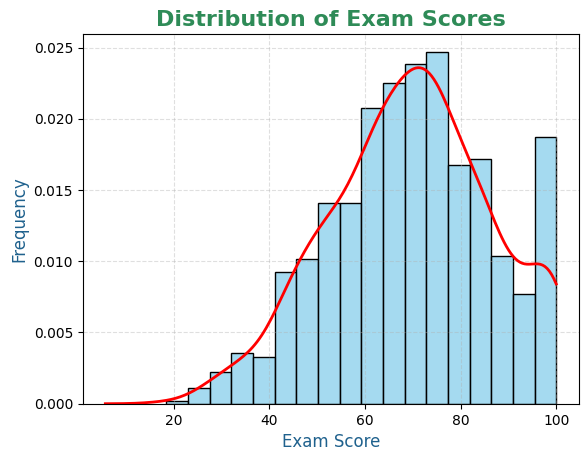

In [75]:
# Vẽ phân phối điểm kiểm tra
sns.histplot(df['exam_score'], color='#87CEEB', stat='density')
sns.kdeplot(df['exam_score'], color='red', linewidth=2,clip=(0,100))
plt.title("Distribution of Exam Scores", color='#2E8B57', fontsize=16, fontweight='bold')
plt.xlabel("Exam Score", fontsize=12,color='#1F618D')

plt.ylabel("Frequency", fontsize=12,color='#1F618D')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

**Xét 4 đối tượng sinh viên**

Kiểm tra xem phân phối dữ liệu và đặc biệt là các yếu tố ảnh hưởng của các đối tượng này có khác nhau gì không?

In [76]:
# Xét 4 đối tượng sinh viên theo phân loại
# Xuất sắc
excellent_students = df[(df['exam_score'] >= 90)]
# Giỏi
good_students = df[(df['exam_score'] >= 80) & (df['exam_score'] < 90)]
# Khá
fair_students = df[(df['exam_score'] >= 60) & (df['exam_score'] < 80)]
# TB-Yếu
weak_students = df[(df['exam_score'] < 60)]

In [77]:
# Kiểm tra số lượng mỗi nhóm
print("Phân bố sinh viên:")
print(f"Xuất sắc (≥90): {len(excellent_students)} ({len(excellent_students)/len(df)*100:.1f}%)")
print(f"Giỏi (80-89): {len(good_students)} ({len(good_students)/len(df)*100:.1f}%)")
print(f"Khá (60-79): {len(fair_students)} ({len(fair_students)/len(df)*100:.1f}%)")
print(f"TB-Yếu (<60): {len(weak_students)} ({len(weak_students)/len(df)*100:.1f}%)")


Phân bố sinh viên:
Xuất sắc (≥90): 126 (12.6%)
Giỏi (80-89): 151 (15.1%)
Khá (60-79): 443 (44.3%)
TB-Yếu (<60): 280 (28.0%)


**Nhận xét:** Phân bố này rất hợp lý với thực tế - đa số sinh viên ở mức Khá, ít sinh viên đạt Xuất sắc.

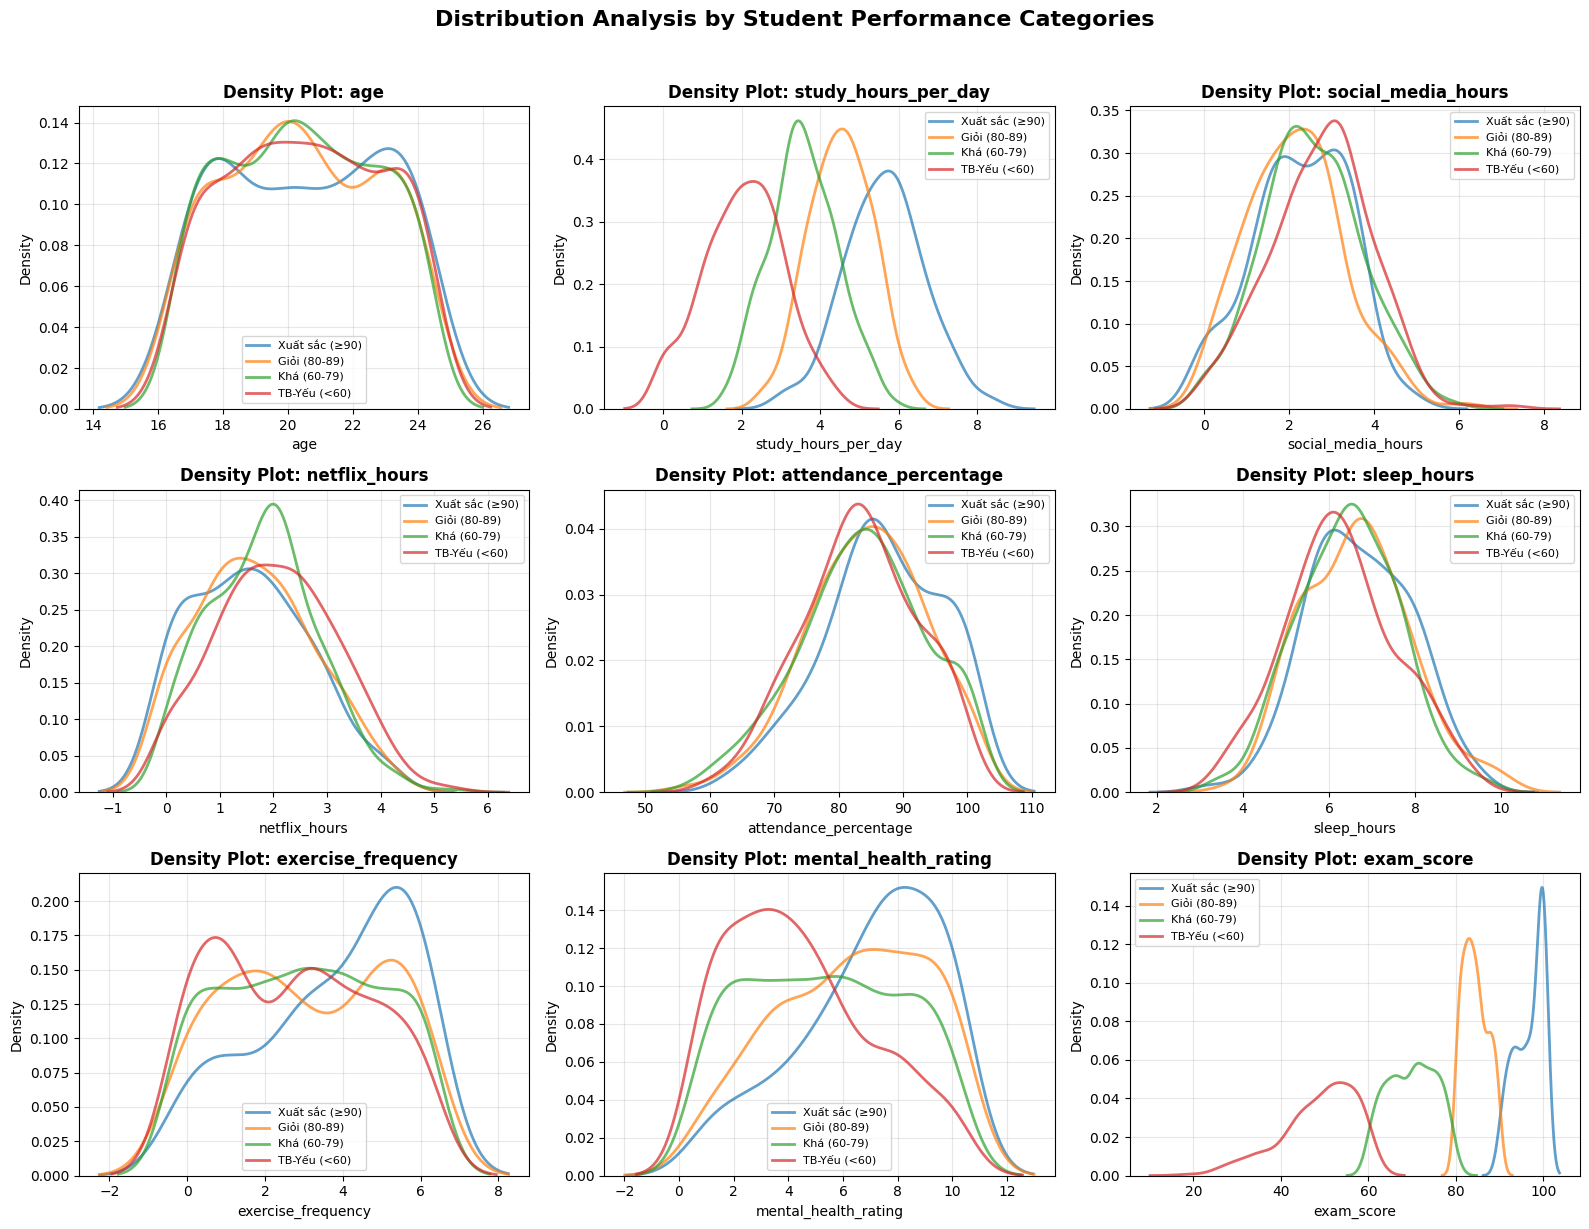

In [78]:
# Vẽ biểu đồ density
numerical_cols = df.select_dtypes(include=['number']).columns
rows = 3
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(16, 12))
axes = axes.flatten()

# Custom color palette cho 4 nhóm
colors = {
    'excellent': '#1f77b4',  # Blue
    'good': '#ff7f0e',       # Orange
    'fair': '#2ca02c',       # Green
    'weak': '#d62728'        # Red
}

# Vẽ biểu đồ density cho từng cột
for i, col in enumerate(numerical_cols):
    # Vẽ từng nhóm với transparency
    sns.kdeplot(data=excellent_students[col], ax=axes[i],
                label=f'Xuất sắc (≥90)',
                color=colors['excellent'], alpha=0.7, linewidth=2)

    sns.kdeplot(data=good_students[col], ax=axes[i],
                label=f'Giỏi (80-89)',
                color=colors['good'], alpha=0.7, linewidth=2)

    sns.kdeplot(data=fair_students[col], ax=axes[i],
                label=f'Khá (60-79)',
                color=colors['fair'], alpha=0.7, linewidth=2)

    sns.kdeplot(data=weak_students[col], ax=axes[i],
                label=f'TB-Yếu (<60)',
                color=colors['weak'], alpha=0.7, linewidth=2)

    axes[i].set_title(f'Density Plot: {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel('Density', fontsize=10)

    # Điều chỉnh legend
    axes[i].legend(fontsize=8, loc='best')
    axes[i].grid(True, alpha=0.3)

# Xóa các ô thừa nếu có
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])

# Tối ưu layout và hiển thị
plt.suptitle('Distribution Analysis by Student Performance Categories',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Nhận xét**:
1. ***STUDY HOURS PER DAY***
- Có ngưỡng rõ ràng: Tăng 1-2h học → tăng 1 bậc học lực  (level performance)

➡️ Quan hệ tuyến tính (Linear relationship) gần như hoàn hảo
- Đây là yếu tố dự đoán đơn tốt nhất (single best predictor) cho học lực

2. ***SOCIAL MEDIA & NETFLIX HOURS***
- Gần như tương đồng (identical) giữa các nhóm: Tất cả đều dùng 2-3h social media và Netflix

➡️ Xóa bỏ lầm tưởng: Social media/Netflix không phải "kẻ thù" của học tập vì ngay cả những người học tốt cũng dành thời gian cho chúng.
- Vấn đề là việc quản lí thời gian (time management)

⌛Việc sử dụng mạng xã hội và Netflix với thời lượng vừa phải không nhất thiết là yếu tố gây hại cho việc học. Thực tế, các nhóm sinh viên khác nhau (kể cả những người học giỏi, xuất sắc) đều có xu hướng sử dụng tương tự nhau. Vấn đề cốt lõi không phải là việc có sử dụng hay không, mà là khả năng quản lý thời gian hiệu quả để đảm bảo cân bằng giữa học tập và giải trí. Những sinh viên xuất sắc vẫn duy trì được sự cân bằng này, cho thấy họ không hoàn toàn "kiêng" các hoạt động giải trí trực tuyến.

3. ***ATTENDANCE PERCENTAGE***
- Xuất sắc: một nhóm 85-90%, một nhóm 95-100%
- Các nhóm khác: Tương tự nhau, peak ở 85-90%

➡️ Attendance cần thiết nhưng không đủ
- Có một số sinh viên Xuất sắc với attendance 85%

➡️ Chất lượng > Số lượng

4. ***SLEEP***
- Tương đồng nhau rất nhiều.
- Đây là điều kiện cơ bản, không phải là yếu tố tạo ra quá nhiều sự khác biệt.

5. ***EXERCISE FREQUENCY***
- Xuất sắc: Peak rõ ở 6 lần/tuần
- Các nhóm khác: Phân bố rộng, không rõ pattern

➡️ Có thể nói việc tập luyện thể dục là thói quen của những sinh viên Xuất sắc. Nó thể hiện Tinh thần kỷ luật và khả năng quản lý thời gian hiệu quả!

6. ***MENTAL HEALTH RATING***
- Tương quan (Correlation) mạnh với thành tích học tập (academic performance).
Có thể là mối quan hệ 2 chiều (bidirectional): Good grades → Better mental health → Better grades

➡️ Mối quan hệ giữa MENTAL HEALTH và ACADEMIC PERFORMANCE không chỉ đơn thuần là một chiều. Thay vào đó, nó có thể là một chu trình tích cực (hoặc tiêu cực nếu theo chiều ngược lại). Thành tích tốt có thể cải thiện sức khỏe tinh thần, và sức khỏe tinh thần tốt hơn lại tiếp tục thúc đẩy thành tích tốt hơn. Đây là một vòng lặp củng cố lẫn nhau. Điều này cũng giải thích tại sao "correlation mạnh" được quan sát thấy.

7. ***EXERCISE FREQUENCY***
- Xuất sắc: Peak rõ ở 6 lần/tuần
- Các nhóm khác: Phân bố rộng, không rõ pattern

➡️ Có thể nói việc làm bài tập thường xuyên là thói quen của những sinh viên Xuất sắc. Nó thể hiện Tinh thần kỷ luật và khả năng quản lý thời gian hiệu quả!


<ipython-input-79-98356c18a852>:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot,
<ipython-input-79-98356c18a852>:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot,
<ipython-input-79-98356c18a852>:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot,
<ipython-input-79-98356c18a852>:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot,


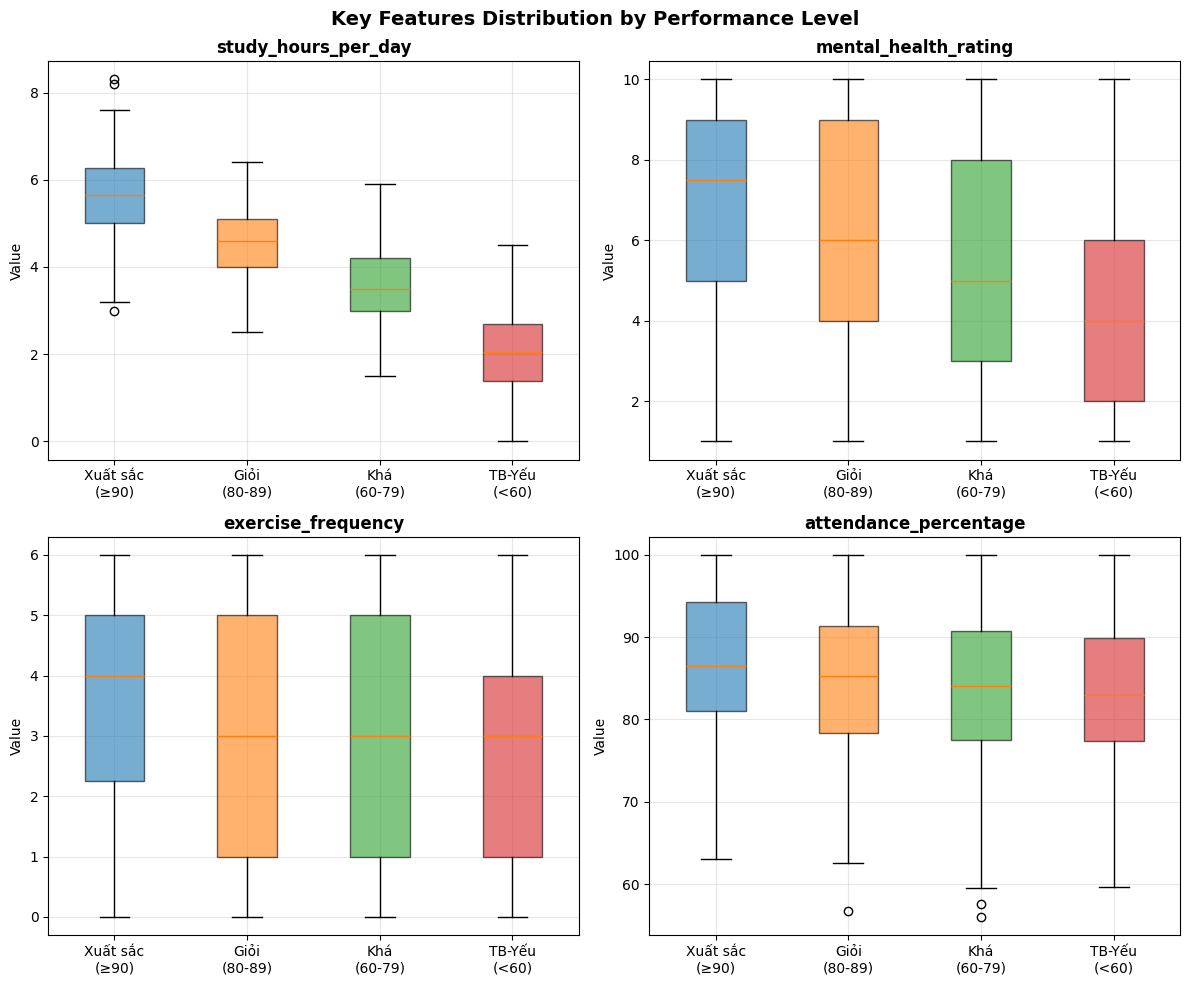

In [79]:
# Tạo subplot riêng cho các features quan trọng nhất
important_features = ['study_hours_per_day', 'mental_health_rating',
                     'exercise_frequency', 'attendance_percentage']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, feature in enumerate(important_features):
    # Box plot kết hợp với strip plot
    data_to_plot = [
        excellent_students[feature].dropna(),
        good_students[feature].dropna(),
        fair_students[feature].dropna(),
        weak_students[feature].dropna()
    ]

    bp = axes[idx].boxplot(data_to_plot,
                           labels=['Xuất sắc\n(≥90)', 'Giỏi\n(80-89)',
                                  'Khá\n(60-79)', 'TB-Yếu\n(<60)'],
                           patch_artist=True)

    # Tô màu cho boxes
    colors_list = [colors['excellent'], colors['good'],
                   colors['fair'], colors['weak']]
    for patch, color in zip(bp['boxes'], colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    axes[idx].set_title(f'{feature}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Value', fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Key Features Distribution by Performance Level',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [80]:
# Tạo bảng thống kê cho từng nhóm
summary_stats = pd.DataFrame()

for name, group in [('Xuất sắc', excellent_students),
                   ('Giỏi', good_students),
                   ('Khá', fair_students),
                   ('TB-Yếu', weak_students)]:

    stats = {
        'Nhóm': name,
        'Số lượng': len(group),
        'Tỷ lệ (%)': f"{len(group)/len(df)*100:.1f}",
        'Study Hours (mean)': f"{group['study_hours_per_day'].mean():.1f}",
        'Mental Health (mean)': f"{group['mental_health_rating'].mean():.1f}",
        'Exercise Freq (mean)': f"{group['exercise_frequency'].mean():.1f}",
        'Attendance (mean)': f"{group['attendance_percentage'].mean():.1f}"
    }

    summary_stats = pd.concat([summary_stats, pd.DataFrame([stats])],
                             ignore_index=True)

print("\n📊 BẢNG THỐNG KÊ TỔNG HỢP:")
print(summary_stats.to_string(index=False))



📊 BẢNG THỐNG KÊ TỔNG HỢP:
    Nhóm  Số lượng Tỷ lệ (%) Study Hours (mean) Mental Health (mean) Exercise Freq (mean) Attendance (mean)
Xuất sắc       126      12.6                5.6                  7.0                  3.8              86.8
    Giỏi       151      15.1                4.5                  6.3                  3.1              84.4
     Khá       443      44.3                3.6                  5.3                  3.0              83.8
  TB-Yếu       280      28.0                2.1                  4.4                  2.7              83.4


**Nhận xét:**
- Nhóm TB-Yếu không chỉ thấp ở một yếu tố mà là thấp đồng đều ở tất cả các yếu tố quan trọng ảnh hưởng đến kết quả học tập được khảo sát.

➡️ 1 "vòng xoáy tiêu cực": học ít, tinh thần không tốt, ít vận động, hay nghỉ học. Các yếu tố này có thể tác động qua lại và kéo nhau xuống. Ví dụ, nghỉ học nhiều dẫn đến không hiểu bài, không có động lực học, dẫn đến căng thẳng (mental health thấp).

- "Mental Health" là yếu tố quan trọng có sự chênh lệch lớn nhất giữa nhóm Xuất sắc (7.0) và TB-Yếu (4.4) – chênh lệch tới 2.6 điểm.

➡️ Điều này tái khẳng định sức khỏe tinh thần không chỉ là hệ quả của việc học tốt/kém, mà còn là một yếu tố đầu vào cực kỳ quan trọng.

- Nhóm "Khá" chiếm tỷ lệ lớn nhất (44.3%) và các chỉ số của họ nằm giữa các thái cực. Đây là nhóm mà những sự thay đổi nhỏ theo hướng tích cực/tiêu cực ở các yếu tố trên có thể tạo ra sự khác biệt lớn, giúp họ tiến vào nhóm "Giỏi"/"TB-Yếu".



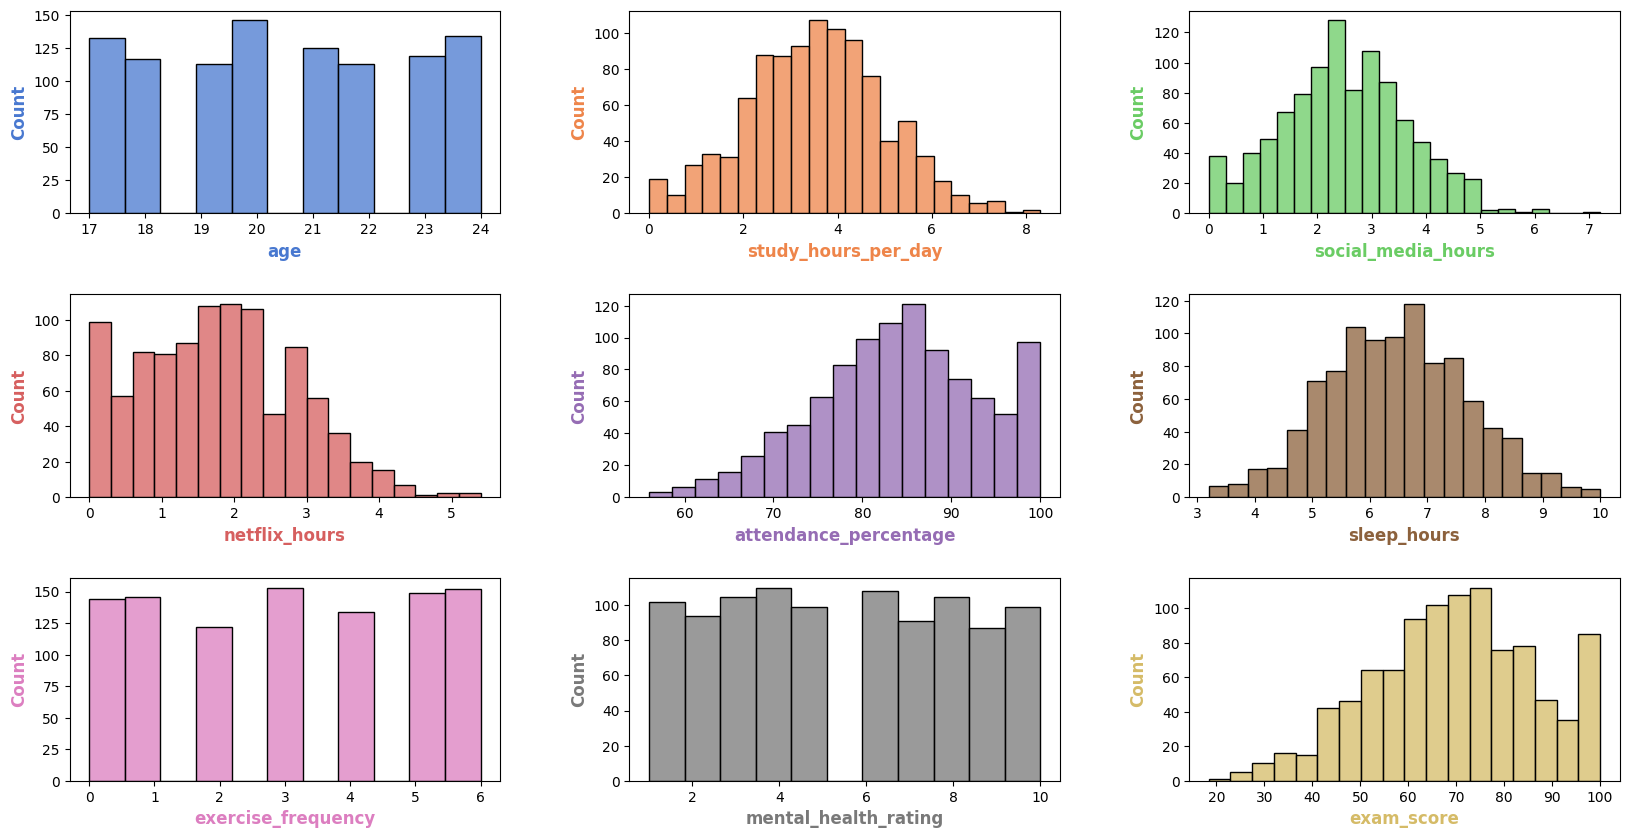

In [81]:
# Vẽ biểu đô histogram cho các biến liên tục
fig, ax = plt.subplots(3, 3, figsize=(20, 10))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

pastel_colors = sns.color_palette("muted", n_colors=9)

for i, col in enumerate(df.select_dtypes(include='number').columns):
    sns.histplot(df[col], ax=ax[i//3, i%3], color=pastel_colors[i])
    ax[i//3, i%3].set_xlabel(f"{col}", fontsize=12, color=pastel_colors[i],fontweight='bold')
    ax[i//3, i%3].set_ylabel("Count", fontsize=12, color=pastel_colors[i],fontweight='bold')

plt.show()

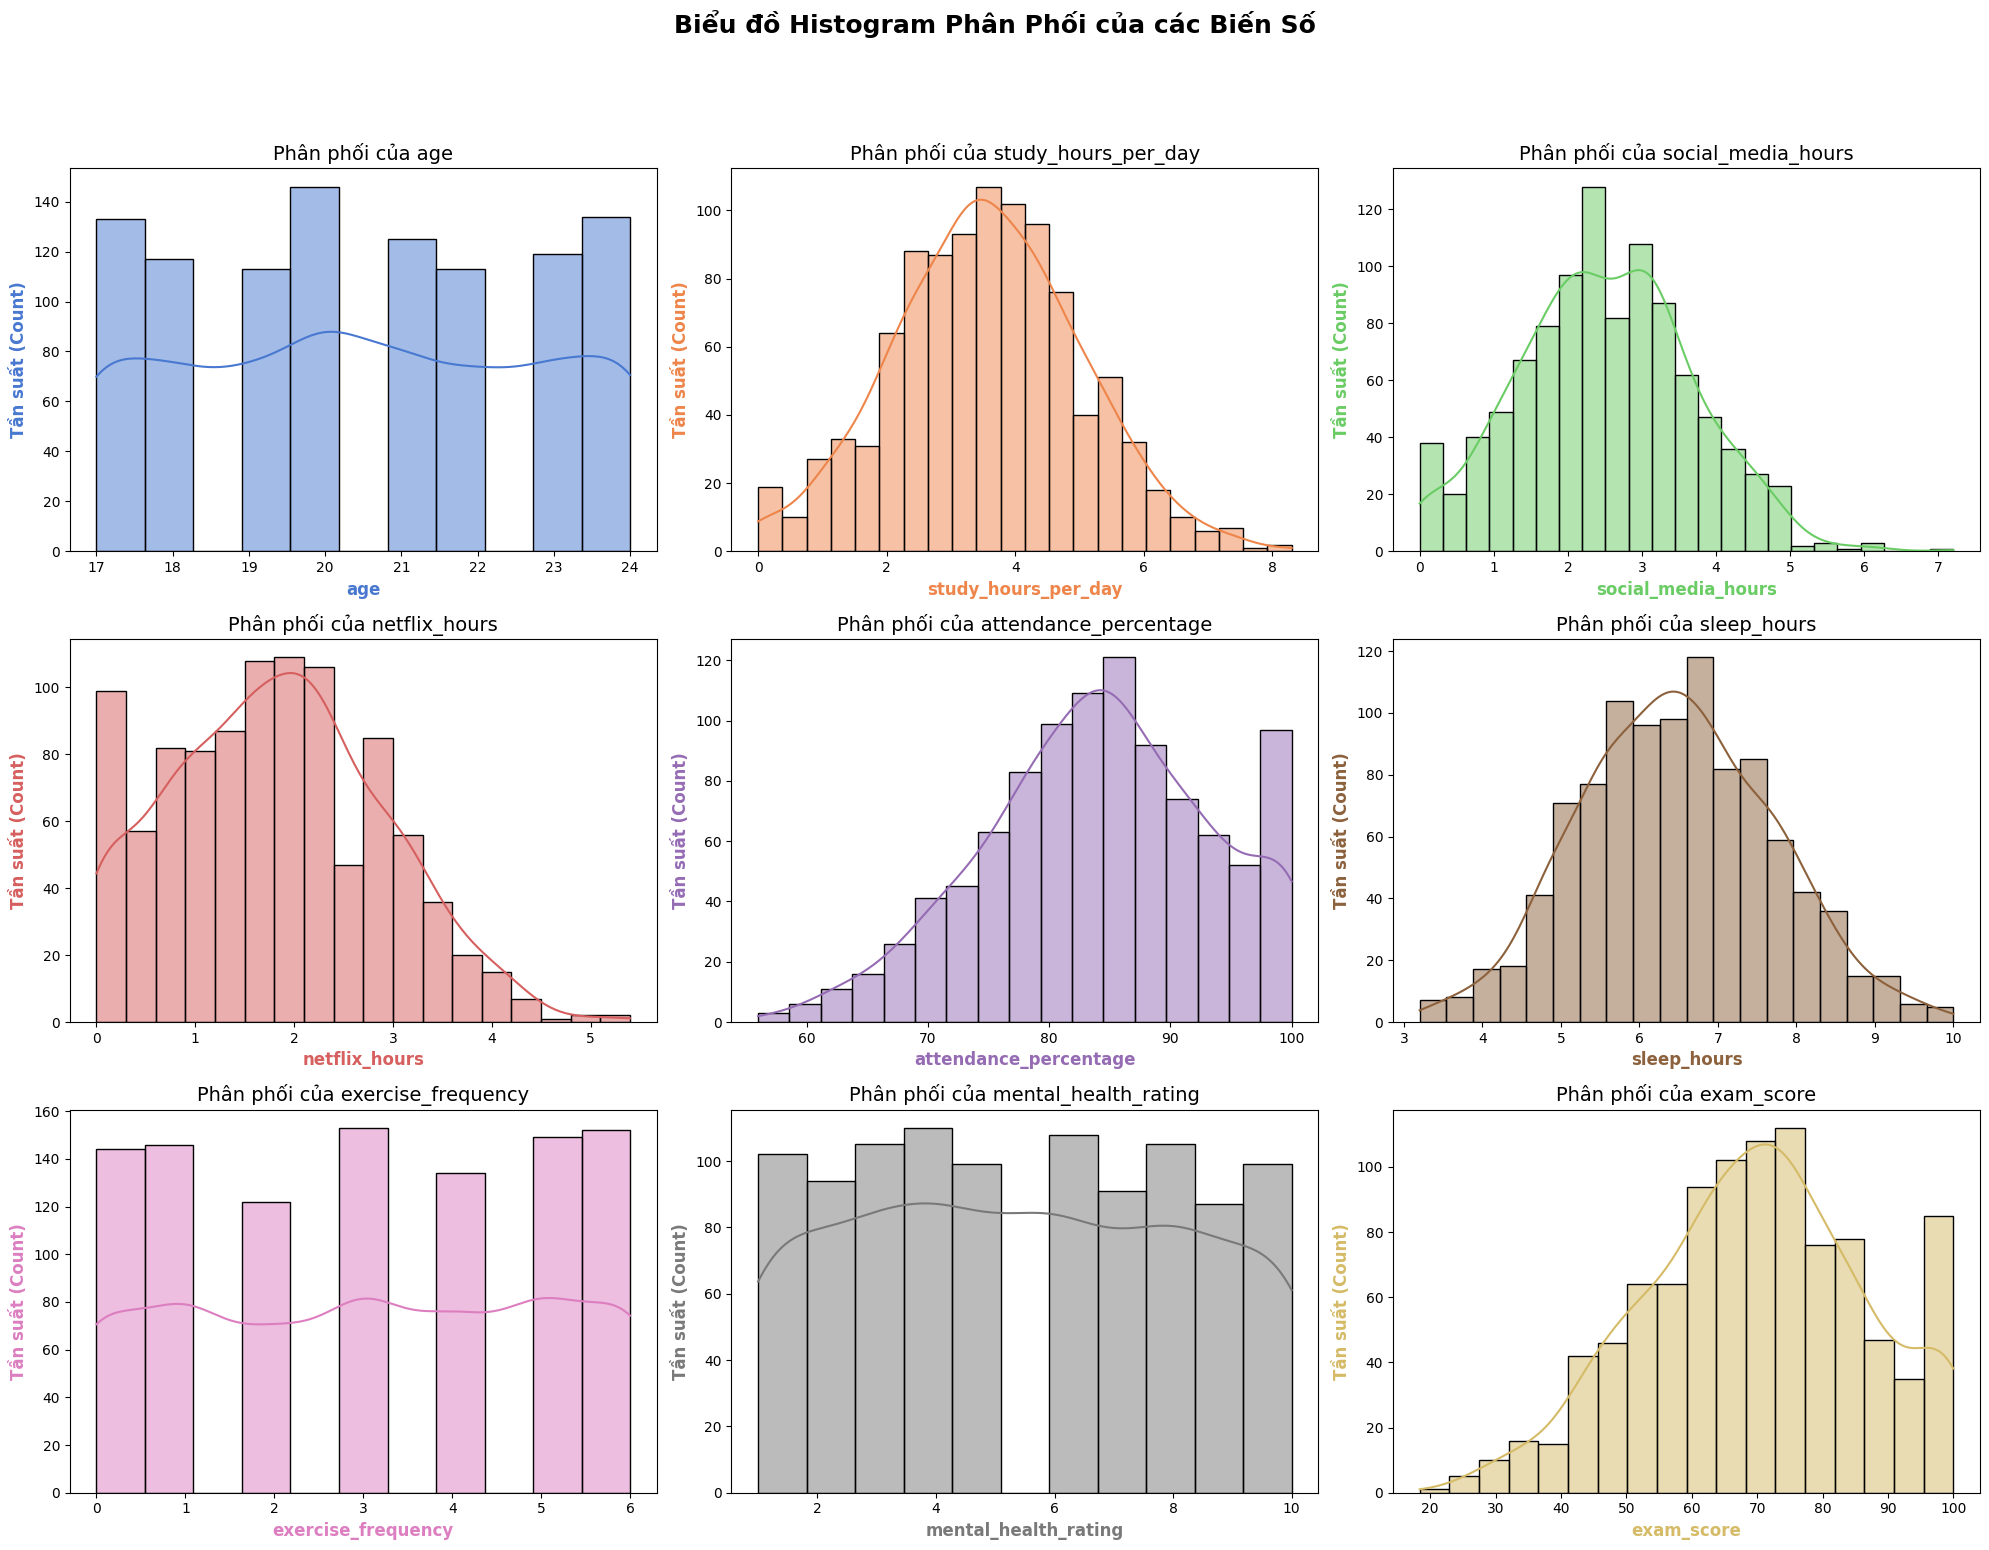


📊 BÁO CÁO ĐỘ XIÊN (SKEWNESS) CỦA CÁC BIẾN SỐ:
                 Biến số  Giá trị Skewness           Phân loại
0                    age          0.008437  Tương đối cân bằng
1  attendance_percentage         -0.237810  Tương đối cân bằng
2             exam_score         -0.156351  Tương đối cân bằng
3     exercise_frequency         -0.031923  Tương đối cân bằng
4   mental_health_rating          0.037811  Tương đối cân bằng
5          netflix_hours          0.237154  Tương đối cân bằng
6            sleep_hours          0.091484  Tương đối cân bằng
7     social_media_hours          0.119805  Tương đối cân bằng
8    study_hours_per_day          0.054253  Tương đối cân bằng


In [82]:
# --- Vẽ biểu đồ Histogram cho các biến số ---
numerical_columns = df.select_dtypes(include='number').columns
num_numerical_cols = len(numerical_columns)

# Xác định số hàng và cột cho subplot, tối đa 3x3
max_plots = 9
cols_plot = 3
rows_plot = (min(num_numerical_cols, max_plots) + cols_plot - 1) // cols_plot

if num_numerical_cols > 0:
    fig, ax = plt.subplots(rows_plot, cols_plot, figsize=(20, 5 * rows_plot))
    fig.subplots_adjust(hspace=0.5, wspace=0.3) # Tăng hspace để tiêu đề không chồng chéo

    # Tạo bảng màu pastel động dựa trên số lượng cột số thực tế
    pastel_colors = sns.color_palette("muted", n_colors=num_numerical_cols)

    ax = ax.flatten() # Làm phẳng mảng axes để dễ truy cập

    for i, col in enumerate(numerical_columns):
        if i >= max_plots:
            print(f"Cảnh báo: Chỉ hiển thị {max_plots} biểu đồ đầu tiên do giới hạn lưới 3x3.")
            break

        sns.histplot(df[col], ax=ax[i], color=pastel_colors[i % len(pastel_colors)], kde=True) # Thêm kde=True
        ax[i].set_xlabel(f"{col}", fontsize=12, color=pastel_colors[i % len(pastel_colors)], fontweight='bold')
        ax[i].set_ylabel("Tần suất (Count)", fontsize=12, color=pastel_colors[i % len(pastel_colors)], fontweight='bold') # Đã Việt hóa
        ax[i].set_title(f"Phân phối của {col}", fontsize=14) # Đã Việt hóa

    # Xóa các ô subplot thừa
    for j in range(i + 1, rows_plot * cols_plot):
        if j < len(ax): # Đảm bảo chỉ số không vượt quá kích thước của ax
             fig.delaxes(ax[j])

    plt.suptitle("Biểu đồ Histogram Phân Phối của các Biến Số", fontsize=18, fontweight='bold', y=1.03) # Đã Việt hóa
    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Điều chỉnh layout để tiêu đề chính không bị cắt
    plt.show()
else:
    print("Không có cột dữ liệu dạng số nào để vẽ biểu đồ.")

# --- Tính toán và phân loại độ xiên (Skewness) ---
if num_numerical_cols > 0:
    # Chỉ lấy các cột số
    num_df = df.select_dtypes(include='number')
    skew_values = num_df.skew() # Mặc định của Pandas là biased (N)

    # Hàm phân loại độ xiên
    def classify_skew(x, left_thr=-0.5, right_thr=0.5):
        if x < left_thr:
            return "Lệch trái (negative)"
        elif x > right_thr:
            return "Lệch phải (positive)"
        else:
            return "Tương đối cân bằng"

    # Tạo DataFrame báo cáo độ xiên
    skew_report = pd.DataFrame({
        "Biến số": skew_values.index, # Thêm cột tên biến số
        "Giá trị Skewness": skew_values.values,
        "Phân loại": skew_values.apply(classify_skew).values # Áp dụng hàm phân loại
    }).sort_values(by="Biến số").reset_index(drop=True) # Sắp xếp theo tên biến và reset index

    print("\n📊 BÁO CÁO ĐỘ XIÊN (SKEWNESS) CỦA CÁC BIẾN SỐ:")
    print(skew_report.to_string())
else:
    print("Không có cột dữ liệu dạng số nào để tính độ xiên.")

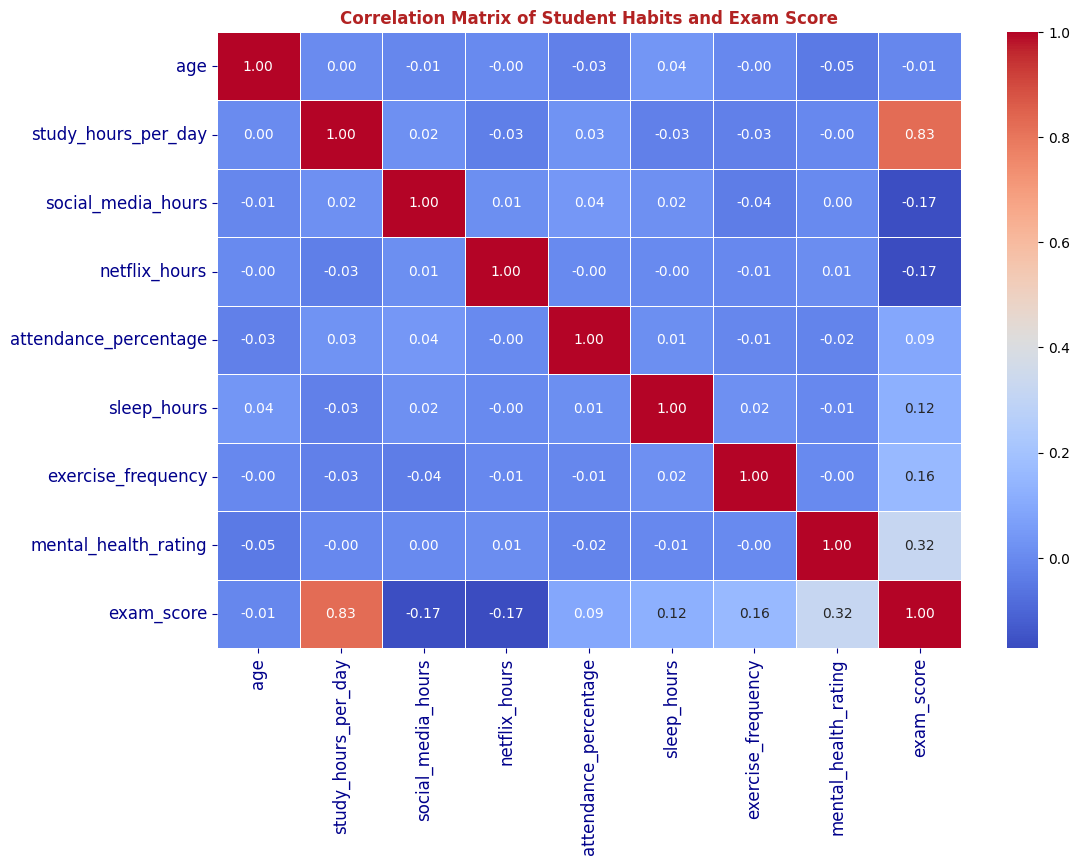

In [83]:
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12, 8))
ax=sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Student Habits and Exam Score",color='#b22222',fontweight='bold')
ax.tick_params(axis='x', colors='#00008b', labelsize=12)
ax.tick_params(axis='y', colors='#00008b', labelsize=12)
plt.show()

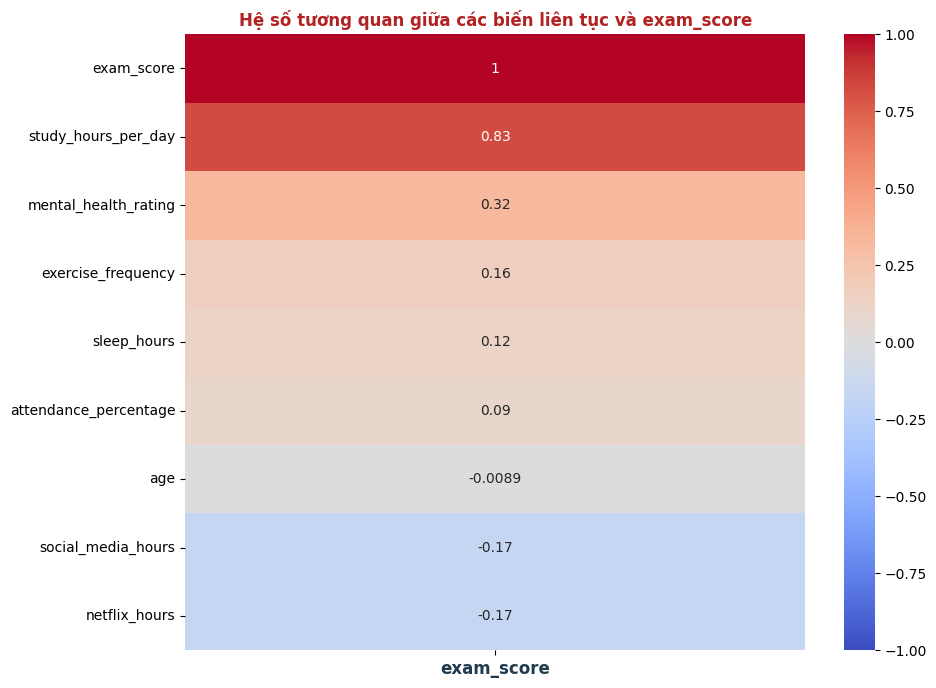

In [84]:
# Chọn các biến số liên tục
continuous_features = list(df.select_dtypes(include='number').columns)
continuous_features.remove('exam_score')

# Tính hệ số tương quan Pearson với exam_score
correlation = df[continuous_features + ['exam_score']].corr()

# Vẽ heatmap hiển thị tương quan
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    correlation[['exam_score']].sort_values(by='exam_score', ascending=False),
    annot=True, cmap='coolwarm', vmin=-1, vmax=1
)
ax.set_xticklabels(ax.get_xticklabels(), color='#1f3b4d', fontweight='bold', fontsize=12)
plt.title('Hệ số tương quan giữa các biến liên tục và exam_score',
          color='#b22222', fontweight='bold')
plt.show()

**Nhận xét:**

- study_hours_per_day: có tương quan rất cao và dương với điểm số. Điều này là dễ hiểu vì học càng nhiều thì thường điểm càng cao.

- mental_health_rating: có tương quan vừa phải và dương – cho thấy sức khỏe tinh thần tốt góp phần cải thiện kết quả học tập.

- exercise_frequency: có tương quan yếu với exam_score, nhưng vẫn mang tính tích cực - cho thấy thể chất cũng có thể ảnh hưởng đến kết quả học tập

-  Các biến như social_media_hours, netflix_hours, sleep_hours có tương quan rất thấp (gần 0)

..............................................................................................................................................................................................................

Tiếp theo ta sẽ biểu đồ scatterplot cho mối tương quan giữa thời gian học hàng này và điểm kiểm tra theo từng biến trên để xem ta có bỏ sót thông tin gì quan trọng không ?


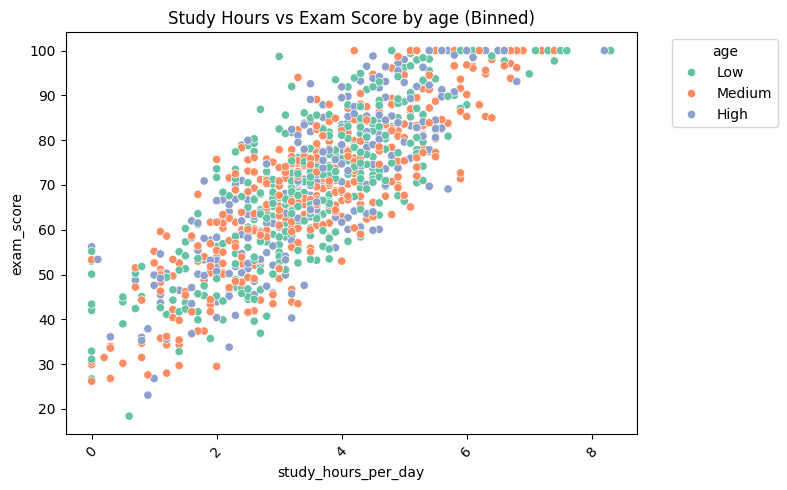

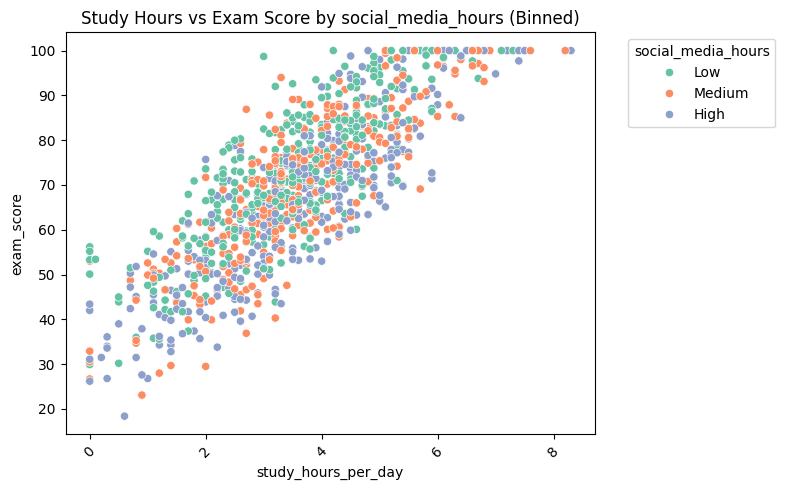

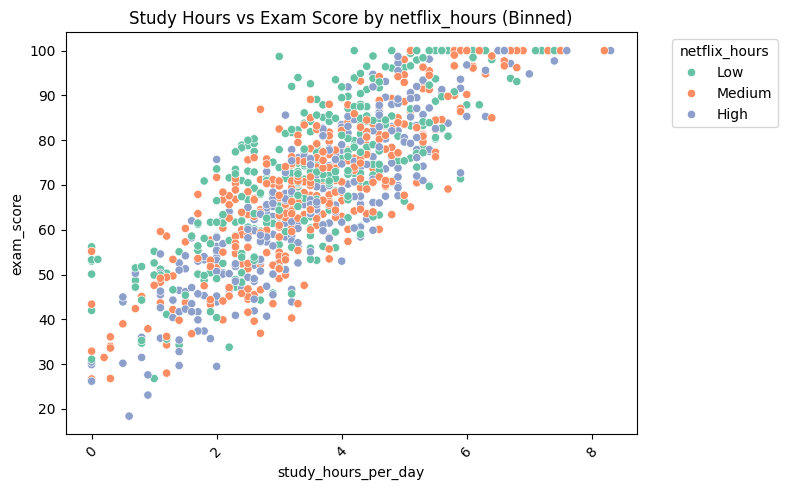

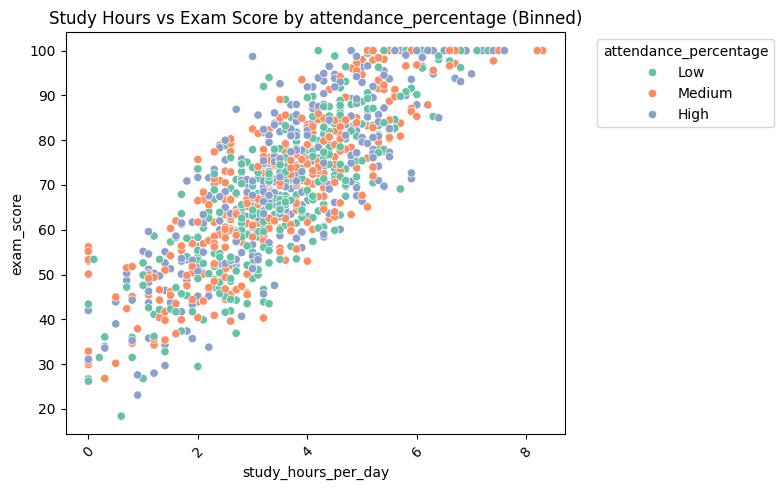

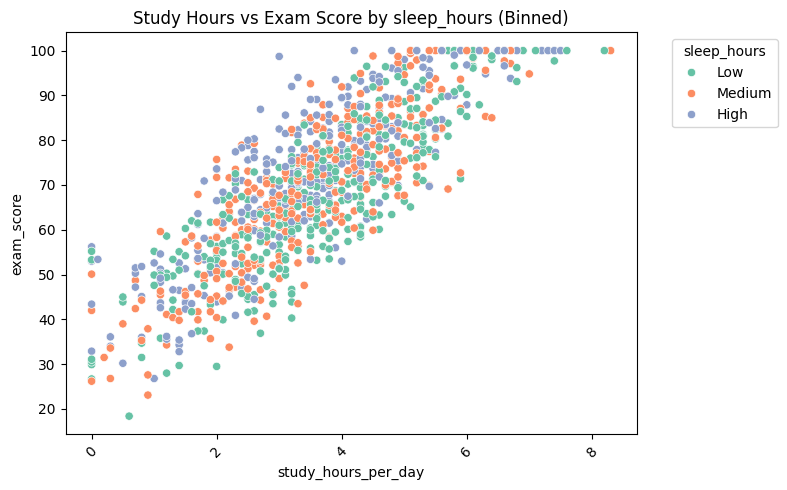

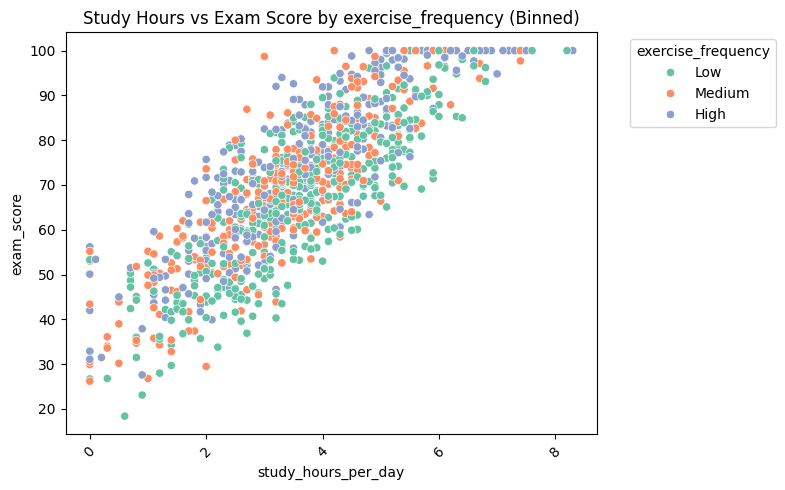

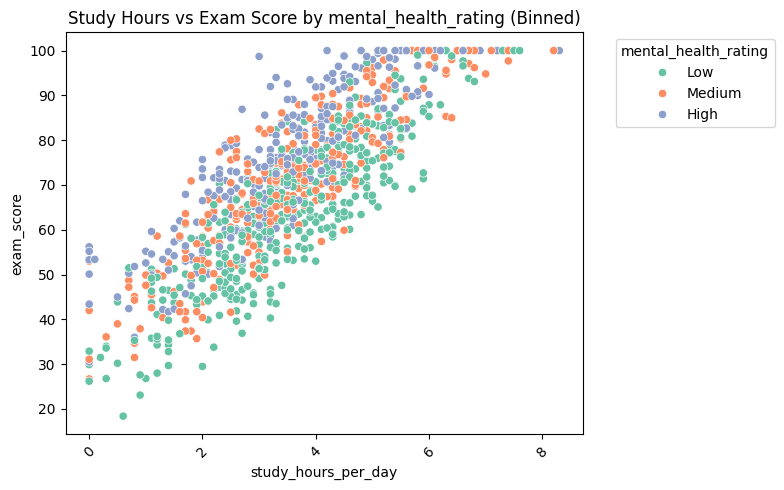

In [85]:
# Danh sách các cột cần chia khoảng
numeric_cols = ['age', 'social_media_hours', 'netflix_hours',
                'attendance_percentage', 'sleep_hours',
                'exercise_frequency', 'mental_health_rating']

# Chia khoảng (binning) bằng pd.qcut với 3 nhóm
for col in numeric_cols:
    df[f'{col}_bin'] = pd.qcut(df[col], q=3, labels=['Low', 'Medium', 'High'])

# Vẽ scatterplot với hue là từng cột đã phân nhóm
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=df,
        x='study_hours_per_day',
        y='exam_score',
        hue=f'{col}_bin',
        palette='Set2'
    )
    plt.title(f'Study Hours vs Exam Score by {col} (Binned)')
    plt.xticks(rotation=45)
    plt.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

**Nhận xét:**
- Cột mental_health_rating: Phần lớn những người học có mức sức khỏe tinh thần từ medium-high nằm trên những người có mức low hơn nếu xét trên các khoảng thời gian học như nhau. Hay nói dễ hiểu là nếu hằng ngày học cùng một khoảng thời gian thì nếu điểm sức khỏe tinh thần cao hơn thì người đó sẽ có xu hướng điểm cao hơn những người điểm sức khỏe tinh thần thấp hơn
- Cột social_media_hours, netflix_hours: Nếu xét điểm học tập là như nhau thì nếu để ý thì các đỉnh chủ yếu là các điểm low-medium và đáy chủ yếu là medium-high. Mặc dù không quá rõ ràng nhưng ta cũng có thể thấy giữa thời gian dùng mạng xã hội, coi phim cũng ảnh hưởng phần nào đến điểm số của học sinh
- Cột exercise_frequency, sleep_hours: Nếu xét điểm học tập là như nhau thì nếu để ý thì các đỉnh chủ yếu là các điểm medium-high và đáy chủ yếu là medium-low. Nên ta có thể thấy phần nào tác động của thời gian tập thể dục và thời gian ngủ đến điểm số của học sinh

**Kết luận**: Dù trên biểu đồ heatmap, các giá trị tương quan của các biến như social_media_hours, netflix_hours, sleep_hours, exercise_frequency nhỏ nhưng khi vẽ biểu đồ phân tán lên ta thấy chúng cũng có quan hệ phần nào với điểm số của học sinh

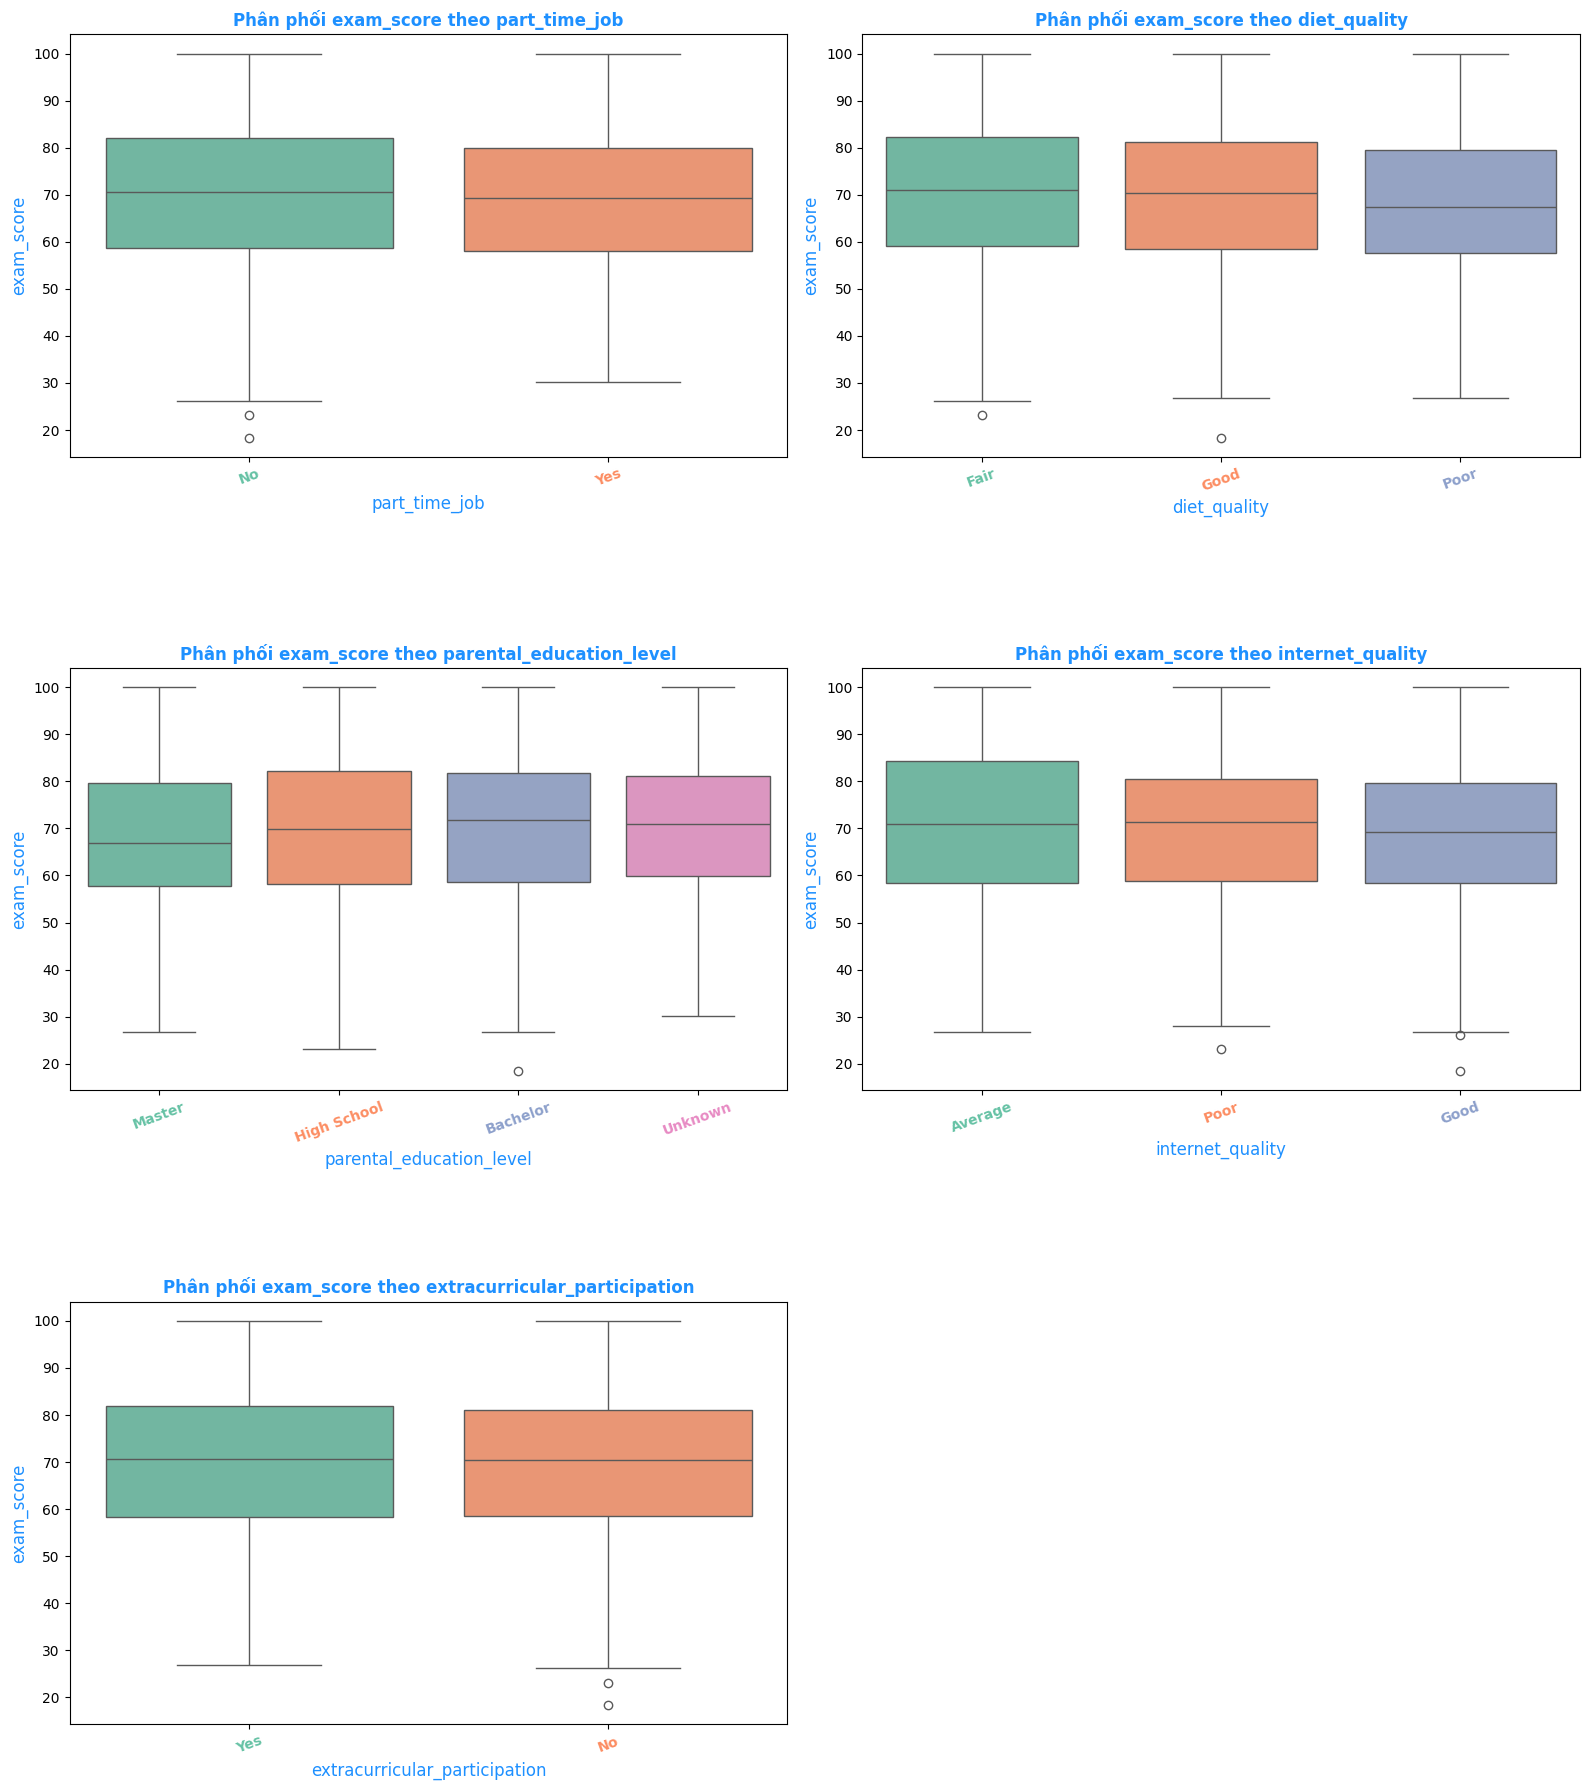

In [86]:
# Các biến phân loại cần khảo sát
categorical_features = list(df.select_dtypes(include = ['object']).columns[1:])

# Vẽ boxplot từng biến phân loại với exam_score
plt.figure(figsize=(16, 18))

title_color = '#1e90ff'
label_color = '#1e90ff'

for i, feature in enumerate(categorical_features):
    plt.subplot(3, 2, i+1)
    unique_cats = df[feature].unique()
    n_cats = len(unique_cats)
    palette = sns.color_palette("Set2", n_colors=n_cats)
    ax = sns.boxplot(x=feature, y='exam_score', data=df, hue=feature,palette=palette,legend=False)


    plt.title(f'Phân phối exam_score theo {feature}', color=title_color, fontweight='bold')
    plt.xlabel(feature, color=label_color, fontsize=12)
    plt.ylabel('exam_score', color=label_color, fontsize=12)
    plt.xticks(rotation=20)


    labels = ax.get_xticklabels()

    # Gán màu cho từng label dựa theo palette tương ứng
    for lbl, color in zip(labels, palette):
        lbl.set_color(color)
        lbl.set_fontweight('bold')

plt.tight_layout()
plt.subplots_adjust(hspace=0.5)
plt.show()


**Nhận xét:**
- Không sự khác biệt đáng kể điểm kiểm tra giữa học sinh có tham gia hay không có tham gia ngoại khóa
- Các thuộc tính có sự khác biệt rõ:
 - diet_quality: Người học có chế độ ăn tốt xu hướng có điểm kiểm tra cao hơn những người có chất lượng chế độ ăn tệ. -> Hợp lý vì ăn ngon thì tinh thần sẽ tốt -> làm bài sẽ điểm cao
 - part_time_job: Người học không làm việc part-time xu hướng có điểm kiểm tra cao hơn người có làm việc part-time -> Có thể do có nhiều thời gian học hơn
 - Internet_quality: Những người học có chất lượng Internet tốt thì điểm có vẻ nhỏ hơn những người có chất lượng Internet từ bình thường hoặc tê. -> Suy đoán: có thể Internet mạnh thì dễ chơi game lướt mạng hơn nên học cũng ít hơn
  - parental_education_level: người học có cha mẹ học vấn Master có vẻ điểm nhỏ hơn những cha mẹ có bằng phổ thông và cử nhân => Suy đoán có thể vì cha mẹ học cao nên con cái cảm thấy áp lực nên học không tốt.

CÁC NHẬN XÉT NÀY CHỈ DỰA VÀO ĐỒ THỊ VẼ TRÊN. CÓ THỂ CÁC SUY LUẬN KHÔNG PHÙ HỢP VỚI THỰC TẾ VÌ CÓ VÀI CỘT DỮ LIỆU PHÂN BỐ KHÔNG ĐỒNG ĐỀU. VÌ LẼ ĐÓ TA CẦN KIỂM ĐỊNH XEM CÁC SUY LUẬN TA CÓ ĐÁNG TIN CẬY HAY KHÔNG.

In [87]:
# Hàm kiểm định trung bình
def perform_tests(data, feature):
    groups = data.groupby(feature)['exam_score'].apply(list)
    if len(groups) == 2:
        # Nếu có 2 nhóm: dùng t-test độc lập
        stat, p_value = ttest_ind(groups.iloc[0], groups.iloc[1], equal_var=False)
        test_name = 'Independent t-test'
    else:
        # Nếu có >2 nhóm: dùng ANOVA
        stat, p_value = f_oneway(*groups)
        test_name = 'One-way ANOVA'
    return test_name, p_value

# Áp dụng kiểm định cho từng biến object
object_features = list(df.select_dtypes(include='object').columns[1:])
results = []
for feature in object_features:
    test_name, p_value = perform_tests(df, feature)
    results.append({'Feature': feature, 'Test': test_name, 'p-value': p_value})

# Chuyển kết quả về DataFrame để hiển thị
results_df = pd.DataFrame(results)
results_df

,Feature,Test,p-value
0,part_time_job,Independent t-test,0.394636
1,diet_quality,One-way ANOVA,0.282352
2,parental_education_level,One-way ANOVA,0.581449
3,internet_quality,One-way ANOVA,0.232035
4,extracurricular_participation,Independent t-test,0.978103


**Nhận xét:**
- Tất cả các p-value điều lớn hơn 0.05. Do đó với mức ý nghĩa 5%, ta không có đủ bằng chứng thống kê để khẳng định rằng trung bình điểm học tập có sự khác giữa các nhóm của từng biến này.

- Như đã đề cập vì số lượng không đồng đều giữa các giá trị của từng nhóm nên việc không đủ bằng chứng để bác bỏ H0 là điều dễ hiểu. Tuy nhiên kết quả kiểm định trên có là vậy thì thực tế có những thuộc tính ta có thể dùng kinh nghiệm thực tế để sủy luận và như các biểu đồ ta vẽ trên thì ta thấy phần nào mối liên hệ giữa các thuộc tính với điểm số học sinh.



#🤖 **3. Xây dựng mô hình**

## 3.1. Xử lý dữ liệu cho xây dựng mô hình

**Nhận xét:**

Thông qua quá trình khám phá dữ liệu, thì ta đã tìm ra các features tiềm năng sau để đưa vào huấn luyện mô hình:
- social_media_hours
- netflix_hours
- sleep_hours
- diet_quality
- parental_education
- internet_quality
- part_time_job
- study_hours_per_day
- mental_health_rating
- excercise_frequency

In [88]:
# Extract các dữ liệu gồm các cột ta chọn
df2 = df[['exam_score', 'social_media_hours', 'netflix_hours', 'sleep_hours',
          'diet_quality', 'parental_education_level', 'internet_quality',
          'part_time_job', 'study_hours_per_day','exercise_frequency','mental_health_rating']]

**Cách xử lý dữ liệu:**

- **Label encoding**:

  - diet_quality

  - parental_education

  - internet_quality

  - mental_health_rating

- **One Hot Encoding** :  
  - part_time_job

- **Normalize (chuẩn hóa)**:
  - social_media_hours

  - netflix_hours

  - sleep_hours

  - study_hours_per_day

  - exercise_frequency


In [89]:
# Chọn các cột cần label encode
ordinal_cols = ['diet_quality', 'parental_education_level', 'internet_quality']

# Xác định thứ tự của từng biến
diet_order = ['Poor', 'Fair', 'Good']
edu_order = ['Unknown', 'High School', 'Bachelor', 'Master']
internet_order = ['Poor', 'Average', 'Good']


# Tạo encoder
encoder = OrdinalEncoder(categories=[diet_order, edu_order, internet_order])

# Áp dụng encoder
df2[ordinal_cols] = encoder.fit_transform(df2[ordinal_cols])



<ipython-input-89-24c7a8d7a504>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[ordinal_cols] = encoder.fit_transform(df2[ordinal_cols])


In [90]:
# Dùng pandas get_dummies
df2 = pd.get_dummies(df2, columns=['part_time_job'], drop_first=True)



In [91]:
# Kiểm tra lại
df2.head()

,exam_score,social_media_hours,netflix_hours,sleep_hours,diet_quality,parental_education_level,internet_quality,study_hours_per_day,exercise_frequency,mental_health_rating,part_time_job_Yes
0,56.2,1.2,1.1,8.0,1.0,3.0,1.0,0.0,6,8,False
1,100.0,2.8,2.3,4.6,2.0,1.0,1.0,6.9,6,8,False
2,34.3,3.1,1.3,8.0,0.0,1.0,0.0,1.4,1,1,False
3,26.8,3.9,1.0,9.2,0.0,3.0,2.0,1.0,4,1,False
4,66.4,4.4,0.5,4.9,1.0,3.0,2.0,5.0,3,1,False


In [92]:
#Chuẩn hóa các giá trị liên tục
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
continuous_cols = ['social_media_hours', 'netflix_hours', 'sleep_hours', 'study_hours_per_day', 'exercise_frequency','mental_health_rating']
df2[continuous_cols] = scaler.fit_transform(df2[continuous_cols])

In [93]:
# Kiểm tra lại
df2

,exam_score,social_media_hours,netflix_hours,sleep_hours,diet_quality,parental_education_level,internet_quality,study_hours_per_day,exercise_frequency,mental_health_rating,part_time_job_Yes
0,56.2,0.166667,0.203704,0.705882,1.0,3.0,1.0,0.000000,1.000000,0.777778,False
1,100.0,0.388889,0.425926,0.205882,2.0,1.0,1.0,0.831325,1.000000,0.777778,False
2,34.3,0.430556,0.240741,0.705882,0.0,1.0,0.0,0.168675,0.166667,0.000000,False
3,26.8,0.541667,0.185185,0.882353,0.0,3.0,2.0,0.120482,0.666667,0.000000,False
4,66.4,0.611111,0.092593,0.250000,1.0,3.0,2.0,0.602410,0.500000,0.000000,False
...,...,...,...,...,...,...,...,...,...,...,...
995,76.1,0.069444,0.296296,0.632353,1.0,1.0,2.0,0.313253,0.333333,0.555556,False
996,65.9,0.138889,0.444444,0.529412,0.0,1.0,1.0,0.349398,0.166667,0.555556,True
997,64.4,0.361111,0.240741,0.485294,2.0,2.0,2.0,0.361446,0.833333,0.888889,False
998,69.7,0.569444,0.203704,0.647059,1.0,2.0,1.0,0.650602,0.000000,0.000000,True


In [94]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   exam_score                1000 non-null   float64
 1   social_media_hours        1000 non-null   float64
 2   netflix_hours             1000 non-null   float64
 3   sleep_hours               1000 non-null   float64
 4   diet_quality              1000 non-null   float64
 5   parental_education_level  1000 non-null   float64
 6   internet_quality          1000 non-null   float64
 7   study_hours_per_day       1000 non-null   float64
 8   exercise_frequency        1000 non-null   float64
 9   mental_health_rating      1000 non-null   float64
 10  part_time_job_Yes         1000 non-null   bool   
dtypes: bool(1), float64(10)
memory usage: 79.2 KB


## 3.2. Huấn luyện mô hình

In [95]:
# Chia tập dữ liệu để huấn luyên
X = df2.drop('exam_score', axis=1)
y = df2['exam_score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [96]:
# Chọn các model để huấn luyện
models = {
   "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}




In [97]:
# Thiết lập đối tượng KFold để chia dữ liệu huấn luyện thành 5 phần (fold)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Tạo một dictionary để lưu kết quả đánh giá từng model
results = {
    'Model': [],
    'RMSE': [],
    'MAE': [],
    'R2': []
}

for name, model in models.items():
    # Cross-validated MSE
    mse_scores = -cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(mse_scores)

    # Cross-validated MAE
    mae_scores = -cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')

    # Cross-validated R²
    r2_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2')

    # Ghi kết quả vào dictionary
    results['Model'].append(name)
    results['RMSE'].append(rmse_scores.mean())
    results['MAE'].append(mae_scores.mean())
    results['R2'].append(r2_scores.mean())

    # In từng model
    print(f"{name} - RMSE: {rmse_scores.mean():.2f}, MAE: {mae_scores.mean():.2f}, R²: {r2_scores.mean():.2f}")

# Chuyển kết quả thành DataFrame
results_df = pd.DataFrame(results)
print(results_df)

Linear Regression - RMSE: 5.61, MAE: 4.48, R²: 0.89
Decision Tree - RMSE: 9.83, MAE: 7.69, R²: 0.67
Random Forest - RMSE: 6.55, MAE: 5.24, R²: 0.85
Gradient Boosting - RMSE: 6.10, MAE: 4.89, R²: 0.87
               Model      RMSE       MAE        R2
0  Linear Regression  5.608757  4.483532  0.890833
1      Decision Tree  9.825096  7.691375  0.665865
2      Random Forest  6.547766  5.236785  0.851337
3  Gradient Boosting  6.102904  4.891386  0.871102


#💬 **4.  Đánh giá & nhận xét**

<ipython-input-98-a59799694936>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results['Model'], y=results['MAE'], palette='Blues_d')
<ipython-input-98-a59799694936>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results['Model'], y=results['RMSE'], palette='Oranges_d')
<ipython-input-98-a59799694936>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results['Model'], y=results['R2'], palette='Greens_d')


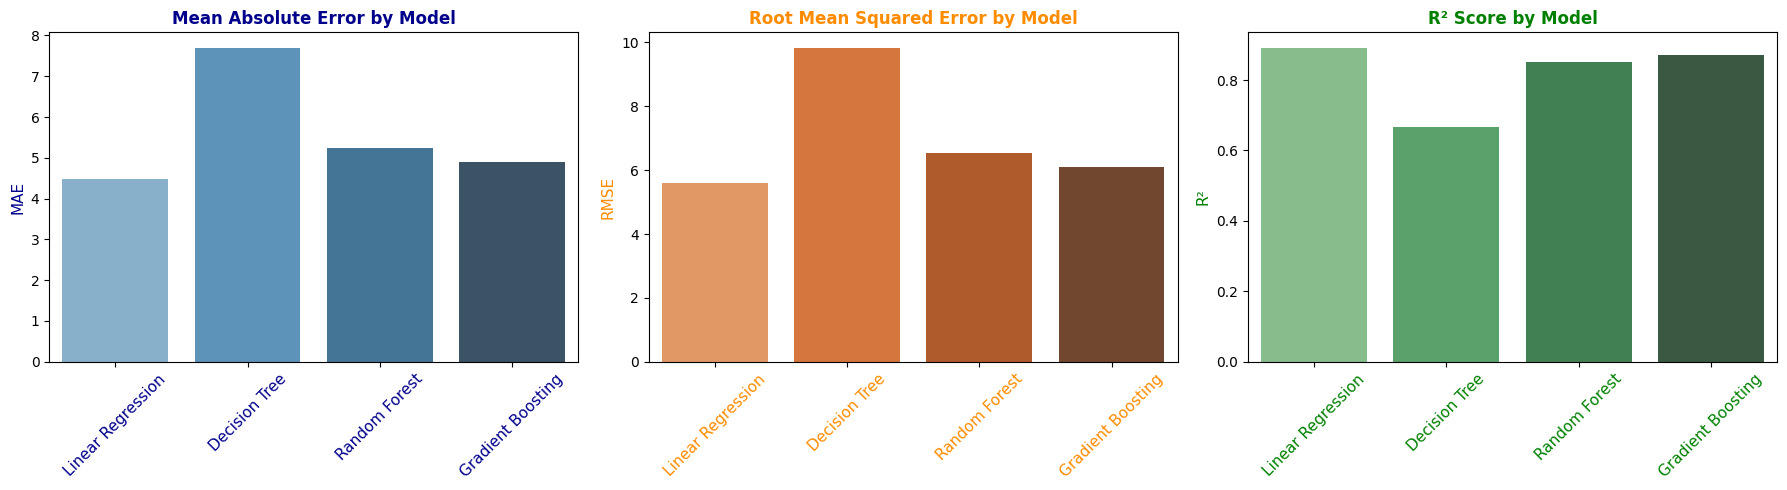

In [98]:
plt.figure(figsize=(18, 5))

# MAE Plot
plt.subplot(1, 3, 1)
sns.barplot(x=results['Model'], y=results['MAE'], palette='Blues_d')
plt.title('Mean Absolute Error by Model', color='#00008b', fontweight='bold')
plt.ylabel('MAE', color='#00008b', fontsize=11)
plt.xticks(color='#00008b', rotation=45, fontsize=11)

# RMSE Plot
plt.subplot(1, 3, 2)
sns.barplot(x=results['Model'], y=results['RMSE'], palette='Oranges_d')
plt.title('Root Mean Squared Error by Model', color='#ff8c00', fontweight='bold')
plt.ylabel('RMSE', color='#ff8c00', fontsize=11)
plt.xticks(color='#ff8c00', rotation=45, fontsize=11)

# R² Plot
plt.subplot(1, 3, 3)
sns.barplot(x=results['Model'], y=results['R2'], palette='Greens_d')
plt.title('R² Score by Model', color='#008000', fontweight='bold')
plt.ylabel('R²', color='#008000', fontsize=11)
plt.xticks(color='#008000', rotation=45, fontsize=11)

plt.tight_layout()
plt.show()

Trong quá trình thực nghiệm, bốn mô hình hồi quy bao gồm Linear Regression, Decision Tree Regressor, Random Forest Regressor và Gradient Boosting Regressor đã được huấn luyện và so sánh thông qua phương pháp K-Fold Cross Validation với 5 lần gập. Hiệu suất của từng mô hình được đánh giá dựa trên các chỉ số: RMSE, MAE và R² Score.
**Nhận xét:**
- Mô hình Linear Regression đạt kết quả tốt nhất với RMSE  ≈ 5.61, MAE  ≈ 4.48 và R²  ≈ 0.89, vượt trội so với các mô hình còn lại.

- Các mô hình cây quyết định (Decision Tree và Random Forest) trường hợp này lại không đạt hiệu quả bằng hồi quy tuyến tính, đặc biệt với Decision Tree có R² thấp ( ≈ 0.67) và sai số cao nhất.

- Gradient Boosting đạt kết quả khá tốt, gần với Linear Regression, tuy nhiên vẫn kém hơn một chút ở cả ba chỉ số đánh giá.

Dựa trên kết quả này, ta chọn mô hình Linear Regression là mô hình tốt nhất hiện tại để đánh giá trên tập test.

In [99]:
# Đánh giá hiệu suất cho mô hình tốt nhất
best_model = LinearRegression()
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Best Model - Linear Regression - MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}")

Best Model - Linear Regression - MAE: 4.27, RMSE: 5.23, R²: 0.89


**Nhận xét:**

- Kết quả trên tập kiểm tra tiếp tục khẳng định khả năng tổng quát hóa tốt của mô hình Linear Regression với R²  ≈ 0.89, đồng nghĩa với việc mô hình giải thích được 89% phương sai của dữ liệu thực tế.

- Sai số trung bình tuyệt đối (MAE) và sai số bình phương trung bình căn (RMSE) lần lượt là  ≈ 4.27 và   ≈ 5.23, thấp hơn so với kết quả trung bình trong quá trình cross-validation. Điều này cho thấy mô hình hoạt động ổn định và nhất quán giữa tập huấn luyện và tập kiểm tra, không có dấu hiệu overfitting.

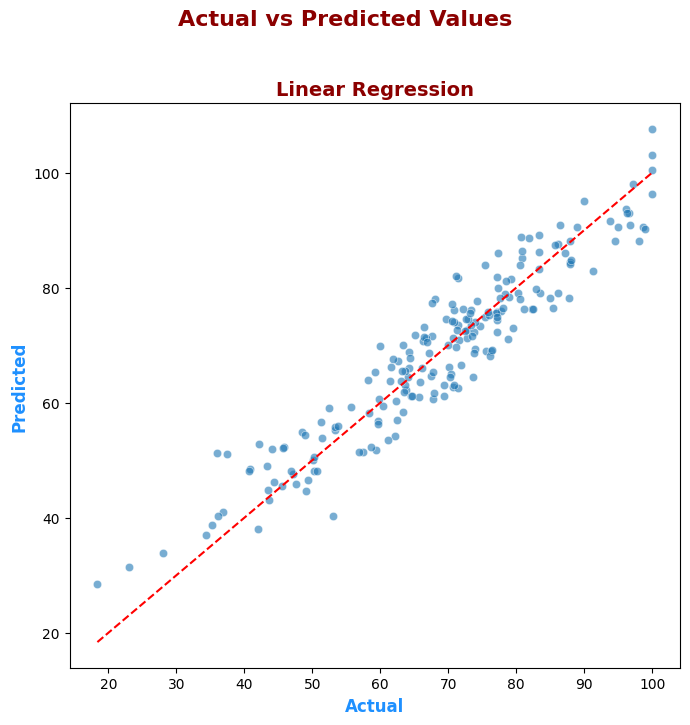

In [100]:

# Tạo scatter plot
plt.figure(figsize=(7, 7))
ax = sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)

# Đường chéo tham chiếu (y = x)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

# Thiết lập tiêu đề và nhãn trục
ax.set_title("Linear Regression", color='#8b0000', fontsize=14, fontweight='bold')
ax.set_xlabel('Actual', color='#1e90ff', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted', color='#1e90ff', fontsize=12, fontweight='bold')

# Suptitle cho toàn bộ figure
plt.suptitle("Actual vs Predicted Values", color='#8b0000', fontsize=16, fontweight='bold', y=1.03)

# Bố cục hợp lý
plt.tight_layout()
plt.show()


#📝 **5. Kết luận & hướng mở rộng**

🔍 **Kết luận:**

Trong dự án này, chúng tôi xây dựng một mô hình dự đoán điểm thi của sinh viên dựa trên các yếu tố liên quan đến đời sống hàng ngày như thời gian học, thói quen sinh hoạt, chế độ dinh dưỡng và sức khỏe tinh thần. Thông qua việc thu thập dữ liệu hành vi và áp dụng các phương pháp phân tích dữ liệu hiện đại, mô hình không chỉ giúp ước lượng kết quả học tập mà còn góp phần khám phá những yếu tố có ảnh hưởng lớn đến thành tích của sinh viên. Sau quá trình triển khai và phân tích, chúng tôi đã rút ra một số nhận định và kết luận sau:

1. Hiệu quả mô hình phụ thuộc vào cấu trúc dữ liệu:  
   
   - Mô hình Linear Regression đạt kết quả tốt nhất trong trường hợp này cho thấy mối quan hệ giữa các yếu tố đầu vào và điểm thi có xu hướng tuyến tính. Điều này cũng đồng nghĩa rằng mô hình phức tạp hơn chưa chắc mang lại hiệu quả nếu không có sự phi tuyến mạnh mẽ hoặc tương tác giữa các đặc trưng.

2. Tầm quan trọng của việc hiểu rõ đặc trưng và ngữ cảnh dữ liệu:

  - Ngoài yếu tố thuật toán, hiệu quả của mô hình dự báo còn phụ thuộc lớn vào việc hiểu rõ bản chất các đặc trưng và bối cảnh thực tế của bài toán. Chỉ khi nắm bắt được ý nghĩa và mối quan hệ tiềm ẩn giữa các yếu tố dữ liệu, ta mới có thể thiết kế các đặc trưng phù hợp, loại bỏ nhiễu, và lựa chọn phương pháp phân tích chính xác. Bài toán này cũng chỉ ra rằng việc trực quan hóa dữ liệu và phân tích tương quan ban đầu đóng vai trò rất quan trọng trong việc định hướng mô hình hóa và lựa chọn thuật toán.



📈 **Mở rộng:**

Việc xây dựng mô hình dự đoán điểm thi không chỉ là bài toán thuật toán mà còn là bài toán hiểu biết dữ liệu và thực tiễn giáo dục. Không có mô hình duy nhất nào là tối ưu cho mọi trường hợp. Sự phù hợp của mô hình phụ thuộc vào chất lượng, cấu trúc và bản chất của dữ liệu, cũng như mục tiêu cụ thể của người sử dụng. Vì vậy, cách tiếp cận hiệu quả nhất là:
- Thử nghiệm nhiều mô hình,
- Đánh giá khách quan bằng các chỉ số phù hợp,
- Hiểu sâu về dữ liệu và ngữ cảnh ứng dụng.

Trong thực tế, mô hình tốt nhất không phải là mô hình chính xác nhất, mà là mô hình đơn giản, dễ giải thích, đáng tin cậy và phù hợp với mục tiêu sử dụng.

Để nâng cao độ chính xác và tính ứng dụng của mô hình, ta có thể xem xét các hướng mở rộng sau:

- Tiền xử lý và chọn lọc đặc trưng

  - Thực hiện tạo đặc trưng mới từ các biến sẵn có nhằm khai thác sâu hơn các mối quan hệ ngầm, ví dụ như tỷ lệ thời gian học tập so với thời gian ngủ, tổng thời gian giải trí mỗi ngày,...

  - Cải thiện phương pháp mã hóa biến phân loại, áp dụng One-Hot Encoding, Ordinal Encoding hoặc Target Encoding tùy theo đặc tính từng biến.

  - Áp dụng các kỹ thuật feature selection như kiểm định thống kê (ANOVA, Chi-square), phân tích độ quan trọng đặc trưng (feature importance) hoặc loại bỏ đặc trưng ít ảnh hưởng nhằm giảm nhiễu và cải thiện hiệu suất tính toán.

- Bổ sung yếu tố ngoại sinh

  - Mở rộng bộ dữ liệu với các yếu tố tâm lý như áp lực gia đình, môi trường học tập, cảm xúc và động lực học tập.

  - Cân nhắc tích hợp dữ liệu theo thời gian (longitudinal data) để phản ánh sự thay đổi của thói quen học tập và kết quả học tập qua từng tuần hoặc tháng.

- Tối ưu hóa mô hình

  - Thực hiện tối ưu siêu tham số cho các mô hình như Random Forest, Gradient Boosting,... bằng Grid Search, Randomized Search hoặc Bayesian Optimization nhằm đạt được hiệu suất dự đoán tối ưu.

  - Kết hợp nhiều mô hình (Ensemble Learning)

  - Triển khai kỹ thuật Voting hoặc Stacking để kết hợp ưu điểm của nhiều mô hình, giảm phương sai và cải thiện độ chính xác tổng thể.

- Ứng dụng thực tiễn

  - Phát triển hệ thống gợi ý cá nhân hóa kế hoạch học tập hoặc cảnh báo sớm rủi ro học tập dựa trên dữ liệu sinh hoạt và kết quả học tập của từng sinh viên, nhằm hỗ trợ công tác tư vấn học tập và quản lý giáo dục.